In [1]:
from PanoDB_link import engine
import pandas as pd
from datetime import datetime
import pytz
import json
import numpy as np

paris = pytz.timezone("Europe/Paris")

mois={
    1 :"janvier",
    2 :"février",
    3 :"mars",
    4 :"avril",
    5 :"mai",
    6 :"juin",
    7 :"juillet",
    8 :"août",
    9 :"septembre",
    10 :"octobre",
    11 :"novembre",
    12 :"décembre",   
}

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm

img_path='images/dashboard/'

In [2]:
# Avec SQLAlchemy engine
logs = pd.read_sql(sql="SELECT * FROM command_logs", con=engine)
logs['executed_at'] = logs['executed_at'].dt.tz_localize('UTC').dt.tz_convert('Europe/Paris')
logs.tail()


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
6699,6700,2025-12-09 23:54:01+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""nom_biblio"": ""Warposa"", ""lien_biblio"": ""http..."
6700,6701,2025-12-09 23:54:23+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""dossier"": ""discord osamodas"", ""nom_biblio"": ..."
6701,6702,2025-12-10 00:52:44+01:00,7.832443e+17,nessuno69057,1.344711e+18,Dofus Touls,1.372978e+18,🤖│spam-bot-maarss,stuff,"{""element"": ""terre feu""}"
6702,6703,2025-12-10 00:56:27+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,supprime_bibliotheque_canal,{}
6703,6704,2025-12-10 00:58:54+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_serveur,"{""dossier"": ""discord osamodas"", ""nom_biblio"": ..."


In [3]:
logs_users=logs[logs["user_name"]!="warp_is_fine"]
logs_users

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
...,...,...,...,...,...,...,...,...,...,...
6694,6695,2025-12-09 22:26:48+01:00,3.544432e+17,vava_le_vrai,1.344711e+18,Dofus Touls,1.348388e+18,🤖│spam-bot,stuff,"{""classe"": ""feca"", ""pa_min"": 12, ""pm_min"": 4, ..."
6695,6696,2025-12-09 22:26:55+01:00,3.544432e+17,vava_le_vrai,1.344711e+18,Dofus Touls,1.348388e+18,🤖│spam-bot,stuff,"{""classe"": ""feca"", ""pa_min"": 12, ""pm_min"": 4, ..."
6696,6697,2025-12-09 23:36:34+01:00,1.205581e+18,shurik0810,1.344711e+18,Dofus Touls,1.348388e+18,🤖│spam-bot,stuff,"{""classe"": ""zobal"", ""element"": ""Terre eau cc""}"
6697,6698,2025-12-09 23:36:34+01:00,1.205581e+18,shurik0810,1.344711e+18,Dofus Touls,1.348388e+18,🤖│spam-bot,stuff,"{""classe"": ""zobal"", ""element"": ""Terre eau""}"


In [4]:
logs_warp=logs[logs["user_name"]=="warp_is_fine"]
logs_warp

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
0,1,2025-09-22 23:53:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
1,2,2025-09-22 23:55:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test""}"
2,3,2025-09-22 23:58:00+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test2""}"
3,4,2025-02-01 23:13:43+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
4,5,2025-02-01 23:15:11+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
...,...,...,...,...,...,...,...,...,...,...
6698,6699,2025-12-09 23:53:26+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""dossier"": ""discord osamodas"", ""nom_biblio"": ..."
6699,6700,2025-12-09 23:54:01+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""nom_biblio"": ""Warposa"", ""lien_biblio"": ""http..."
6700,6701,2025-12-09 23:54:23+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""dossier"": ""discord osamodas"", ""nom_biblio"": ..."
6702,6703,2025-12-10 00:56:27+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,supprime_bibliotheque_canal,{}


In [5]:
nb_logs=len(logs)
nb_logs_users=len(logs_users)
nb_logs_guild_id_null=len(logs[logs["guild_id"].isna()])
nb_logs_guild_id_null_unique=len(logs[logs["guild_id"].isna()]["guild_name"].unique())
nb_guild_names=len(logs["guild_name"].unique())
nb_logs_channel_id_null=len(logs[logs["channel_id"].isna()])
nb_logs_channel_id_null_unique=len(logs[logs["channel_id"].isna()]["channel_name"].unique())
nb_channel_names=len(logs["channel_name"].unique())
nb_logs_user_id_null=len(logs[logs["user_id"].isna()])
nb_logs_user_id_null_unique=len(logs[logs["user_id"].isna()]["user_name"].unique())
nb_user_names=len(logs["user_name"].unique())

print(f"Nombre de logs : {nb_logs}")
print(f"Nombre de logs sans warp : {nb_logs_users}")
print(f"Nombre de guilds : {nb_guild_names}")
print(f"Nombre de channels : {nb_channel_names}")
print(f"Nombre de users : {nb_user_names}")
print(f"Nombre de logs avec guild_id NULL : {nb_logs_guild_id_null} pour {nb_logs_guild_id_null_unique} uniques guild_name")
print(f"Nombre de logs avec channel_id NULL : {nb_logs_channel_id_null} pour {nb_logs_channel_id_null_unique} uniques channel_name")
print(f"Nombre de logs avec user_id NULL : {nb_logs_user_id_null} pour {nb_logs_user_id_null_unique} uniques user_name")


Nombre de logs : 6704
Nombre de logs sans warp : 5236
Nombre de guilds : 148
Nombre de channels : 259
Nombre de users : 755
Nombre de logs avec guild_id NULL : 193 pour 17 uniques guild_name
Nombre de logs avec channel_id NULL : 359 pour 39 uniques channel_name
Nombre de logs avec user_id NULL : 315 pour 104 uniques user_name


# commandes à un temps précis

In [6]:
logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\364389784.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
125,126,2025-02-05 18:20:31+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""patate""}"
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
129,130,2025-02-06 23:25:26+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""feu""}"
...,...,...,...,...,...,...,...,...,...,...
6699,6700,2025-12-09 23:54:01+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""nom_biblio"": ""Warposa"", ""lien_biblio"": ""http..."
6700,6701,2025-12-09 23:54:23+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,change_bibliotheque_canal,"{""dossier"": ""discord osamodas"", ""nom_biblio"": ..."
6701,6702,2025-12-10 00:52:44+01:00,7.832443e+17,nessuno69057,1.344711e+18,Dofus Touls,1.372978e+18,🤖│spam-bot-maarss,stuff,"{""element"": ""terre feu""}"
6702,6703,2025-12-10 00:56:27+01:00,3.579606e+17,warp_is_fine,1.344711e+18,Dofus Touls,1.448069e+18,🤖│spam-bot-osamodas,supprime_bibliotheque_canal,{}


# commandes d'un serveur précis

In [7]:
logs_users.loc[logs_users["guild_id"]==933448236939743360.0]
# logs_users.loc[logs_users["guild_name"]=="La Secte"]

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
134,135,2025-02-09 10:21:48+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""xelor""}"
139,140,2025-02-13 17:58:41+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu""}"
140,141,2025-02-13 17:59:05+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
...,...,...,...,...,...,...,...,...,...,...
6599,6600,2025-12-07 16:40:44+01:00,3.364866e+17,seigneurs,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
6616,6617,2025-12-07 20:18:27+01:00,7.053259e+17,postar1782,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
6625,6626,2025-12-08 08:45:33+01:00,9.483770e+17,manzanna.,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""sadida"", ""element"": ""terre""}"
6636,6637,2025-12-08 16:10:46+01:00,2.919459e+17,cedp,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""zobal"", ""element"": ""terre""}"


# commandes d'un utilisateur précis

In [8]:
user="horaj_"
logs.loc[logs["user_name"]==user]

# userid=357960636509978624
# logs.loc[logs["user_id"]==userid]


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
2604,2605,2025-08-01 01:36:55+02:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
3464,3465,2025-09-09 14:54:06+02:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
5647,5648,2025-11-10 10:35:23+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""enutrof""}"
5652,5653,2025-11-10 14:52:35+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,{}
6126,6127,2025-11-23 14:17:20+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""terre air""}"
6127,6128,2025-11-23 14:17:56+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""sram"", ""element"": ""terre air""}"
6128,6129,2025-11-23 14:22:28+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""steamer""}"
6158,6159,2025-11-24 09:07:37+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""terre""}"
6376,6377,2025-11-30 08:33:48+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""steamer""}"
6410,6411,2025-12-01 04:01:42+01:00,6.949281e+17,horaj_,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""classe"": ""eniripsa""}"


# utilisation des commandes

## utilisation des commandes utilisateurs

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\2546654622.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\2546654622.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\2546654622.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

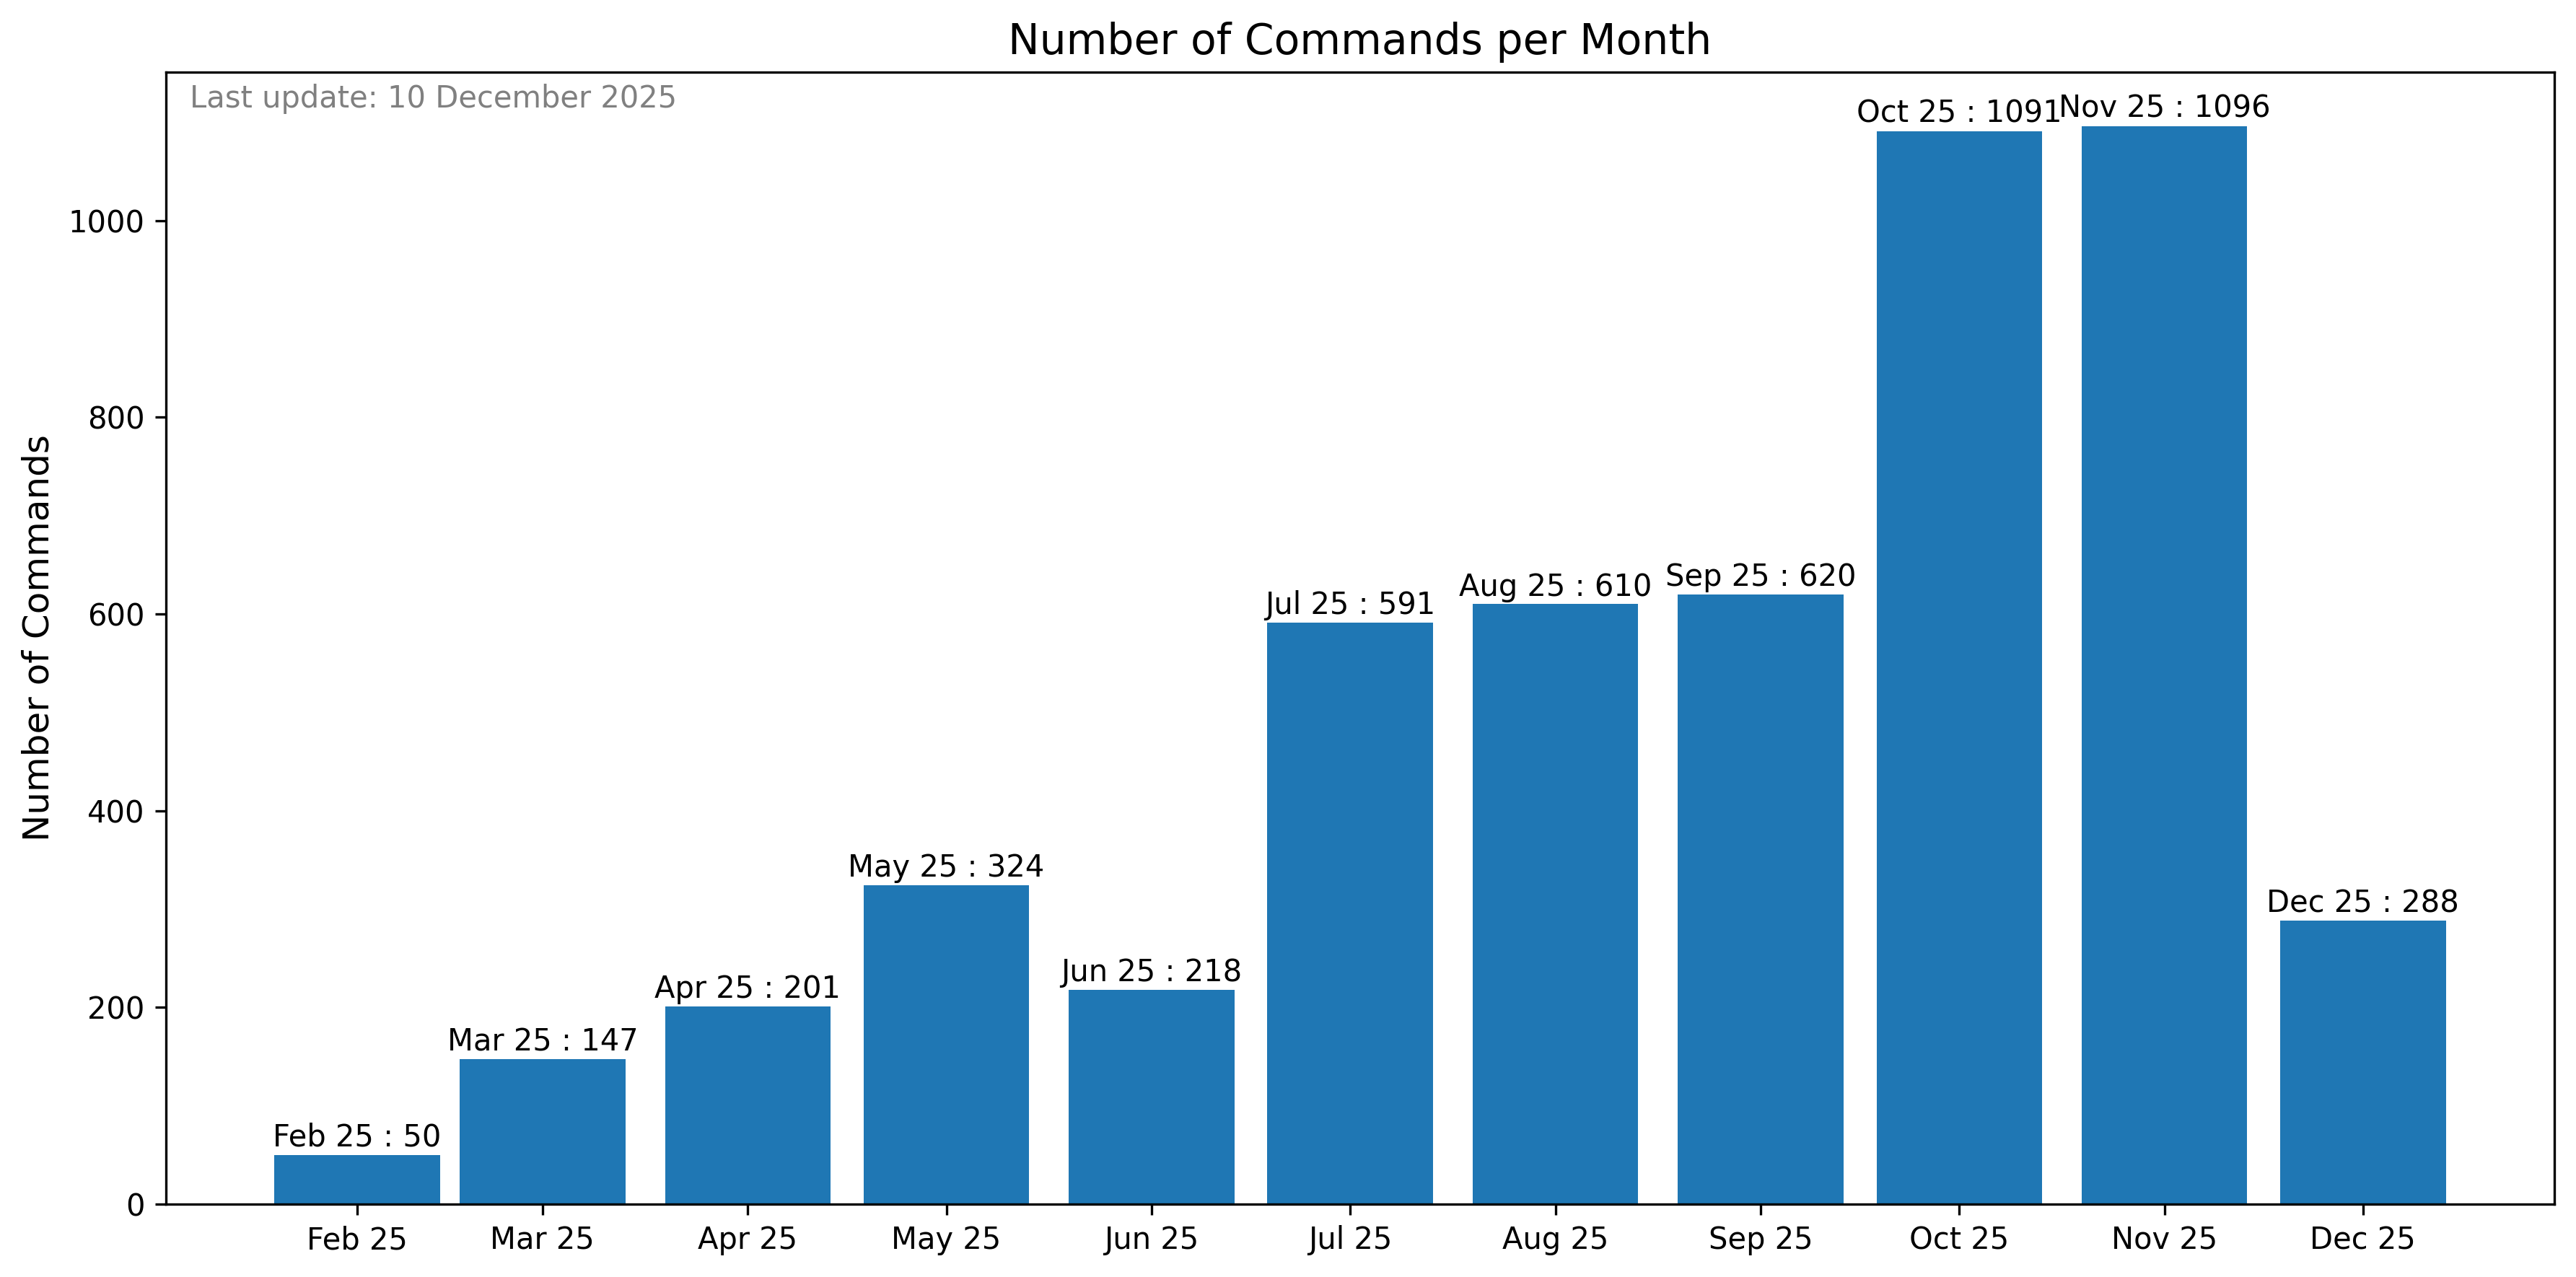

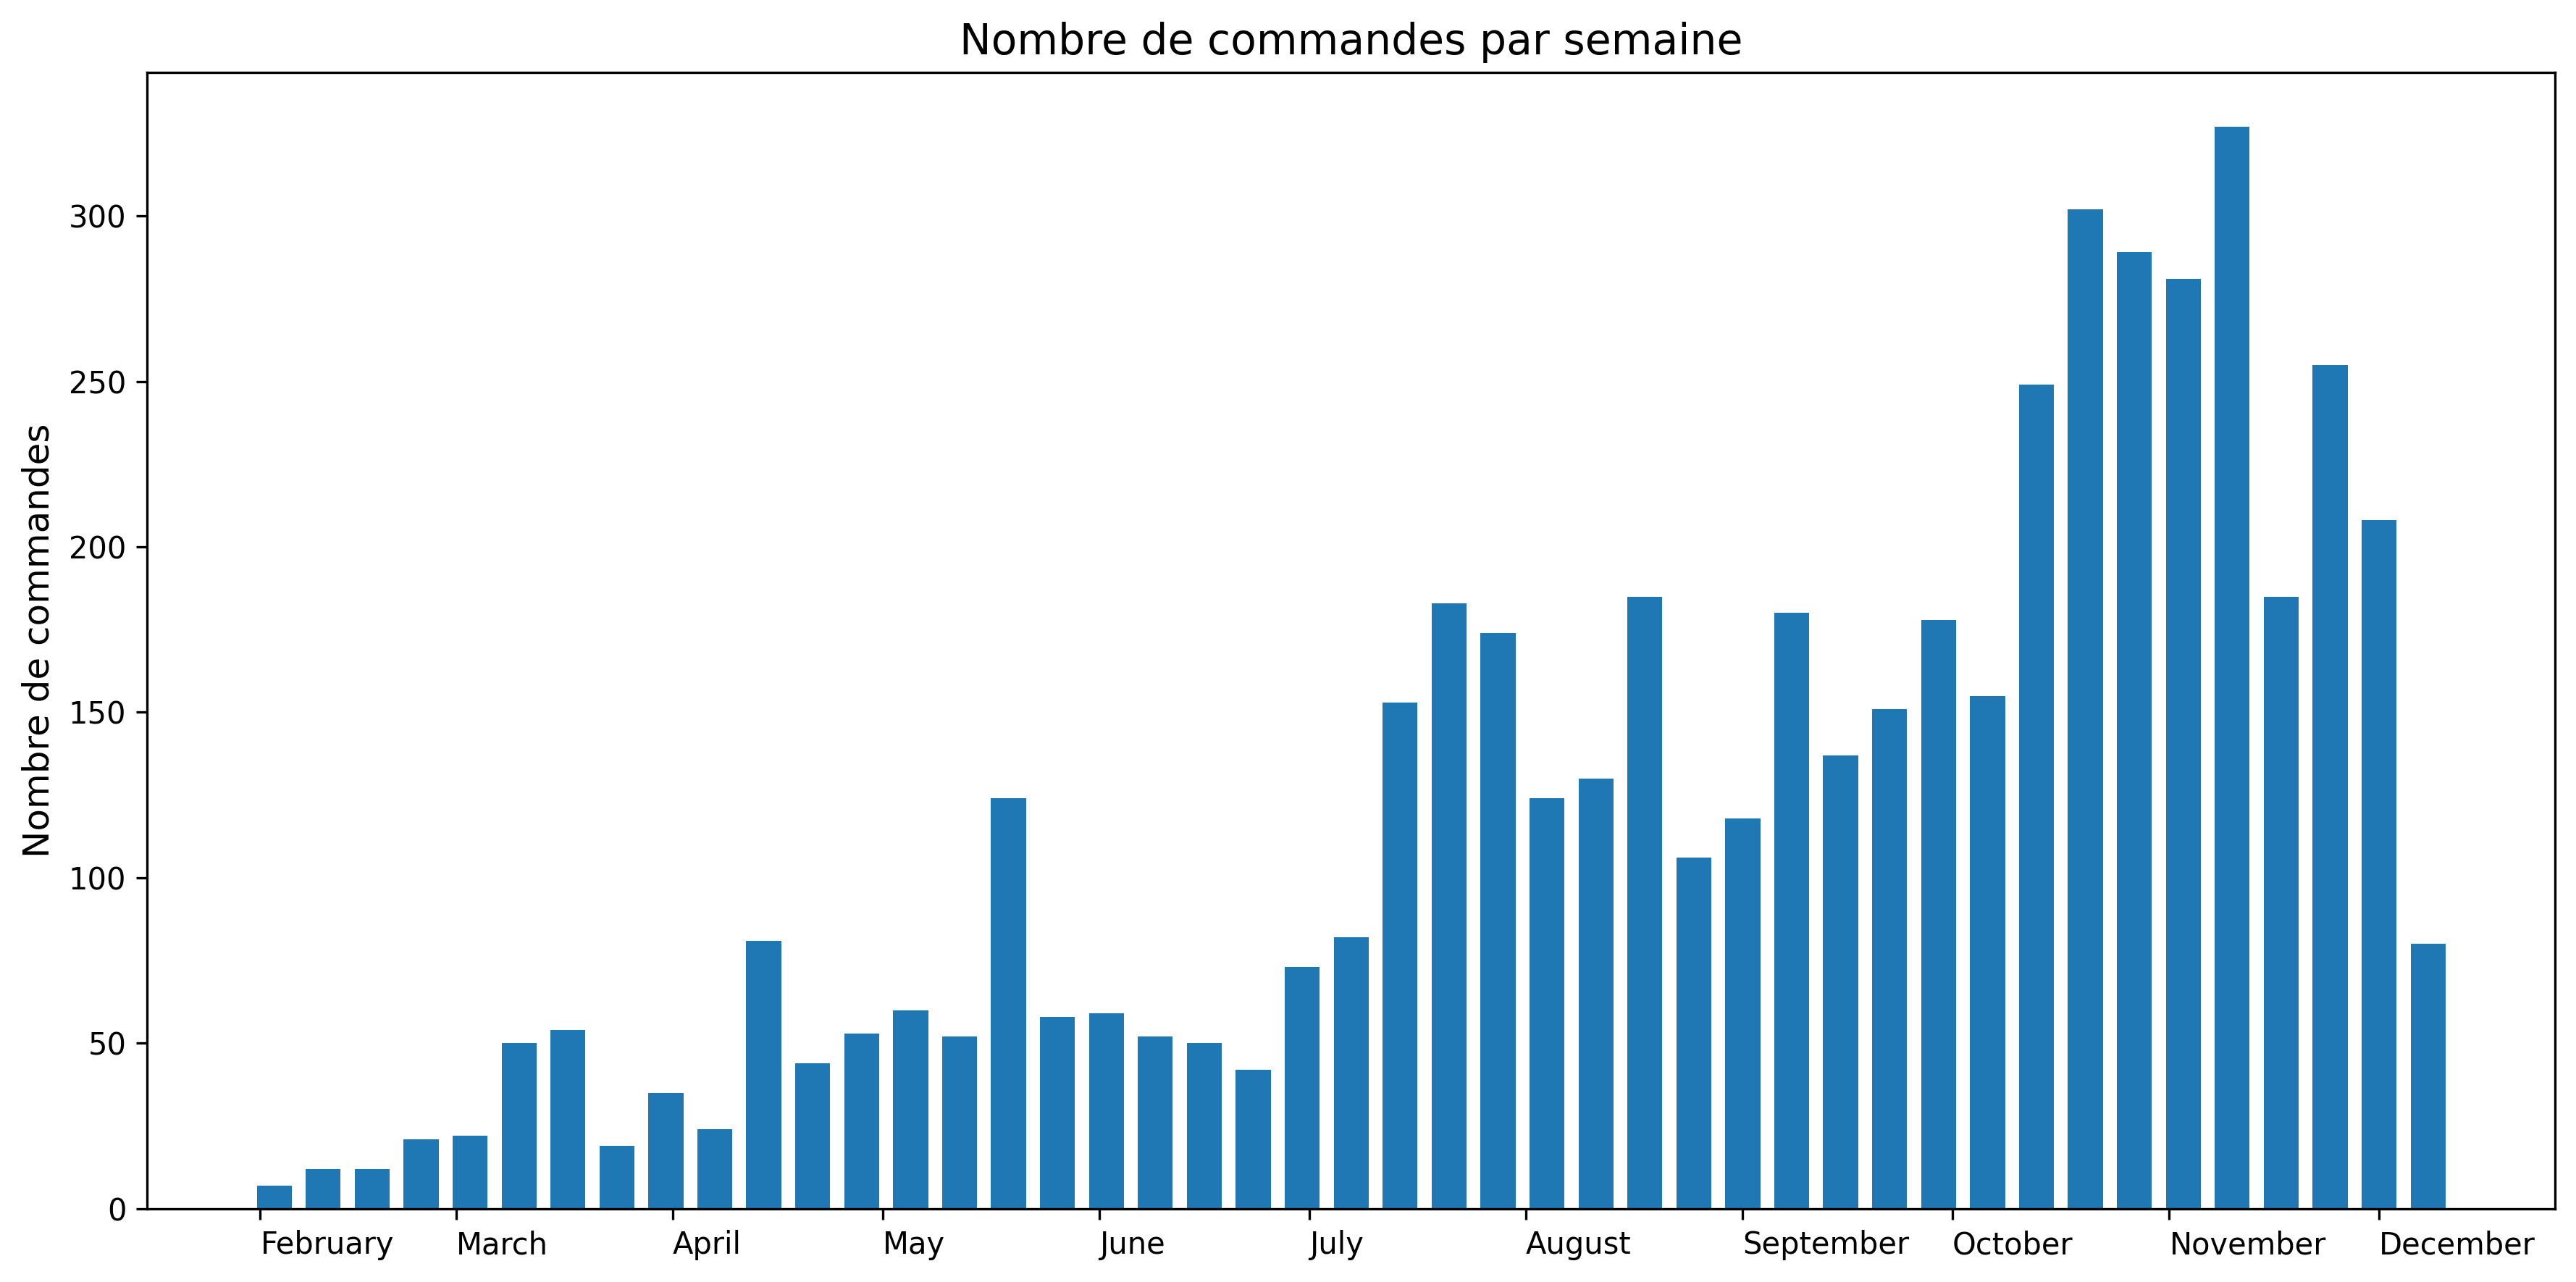

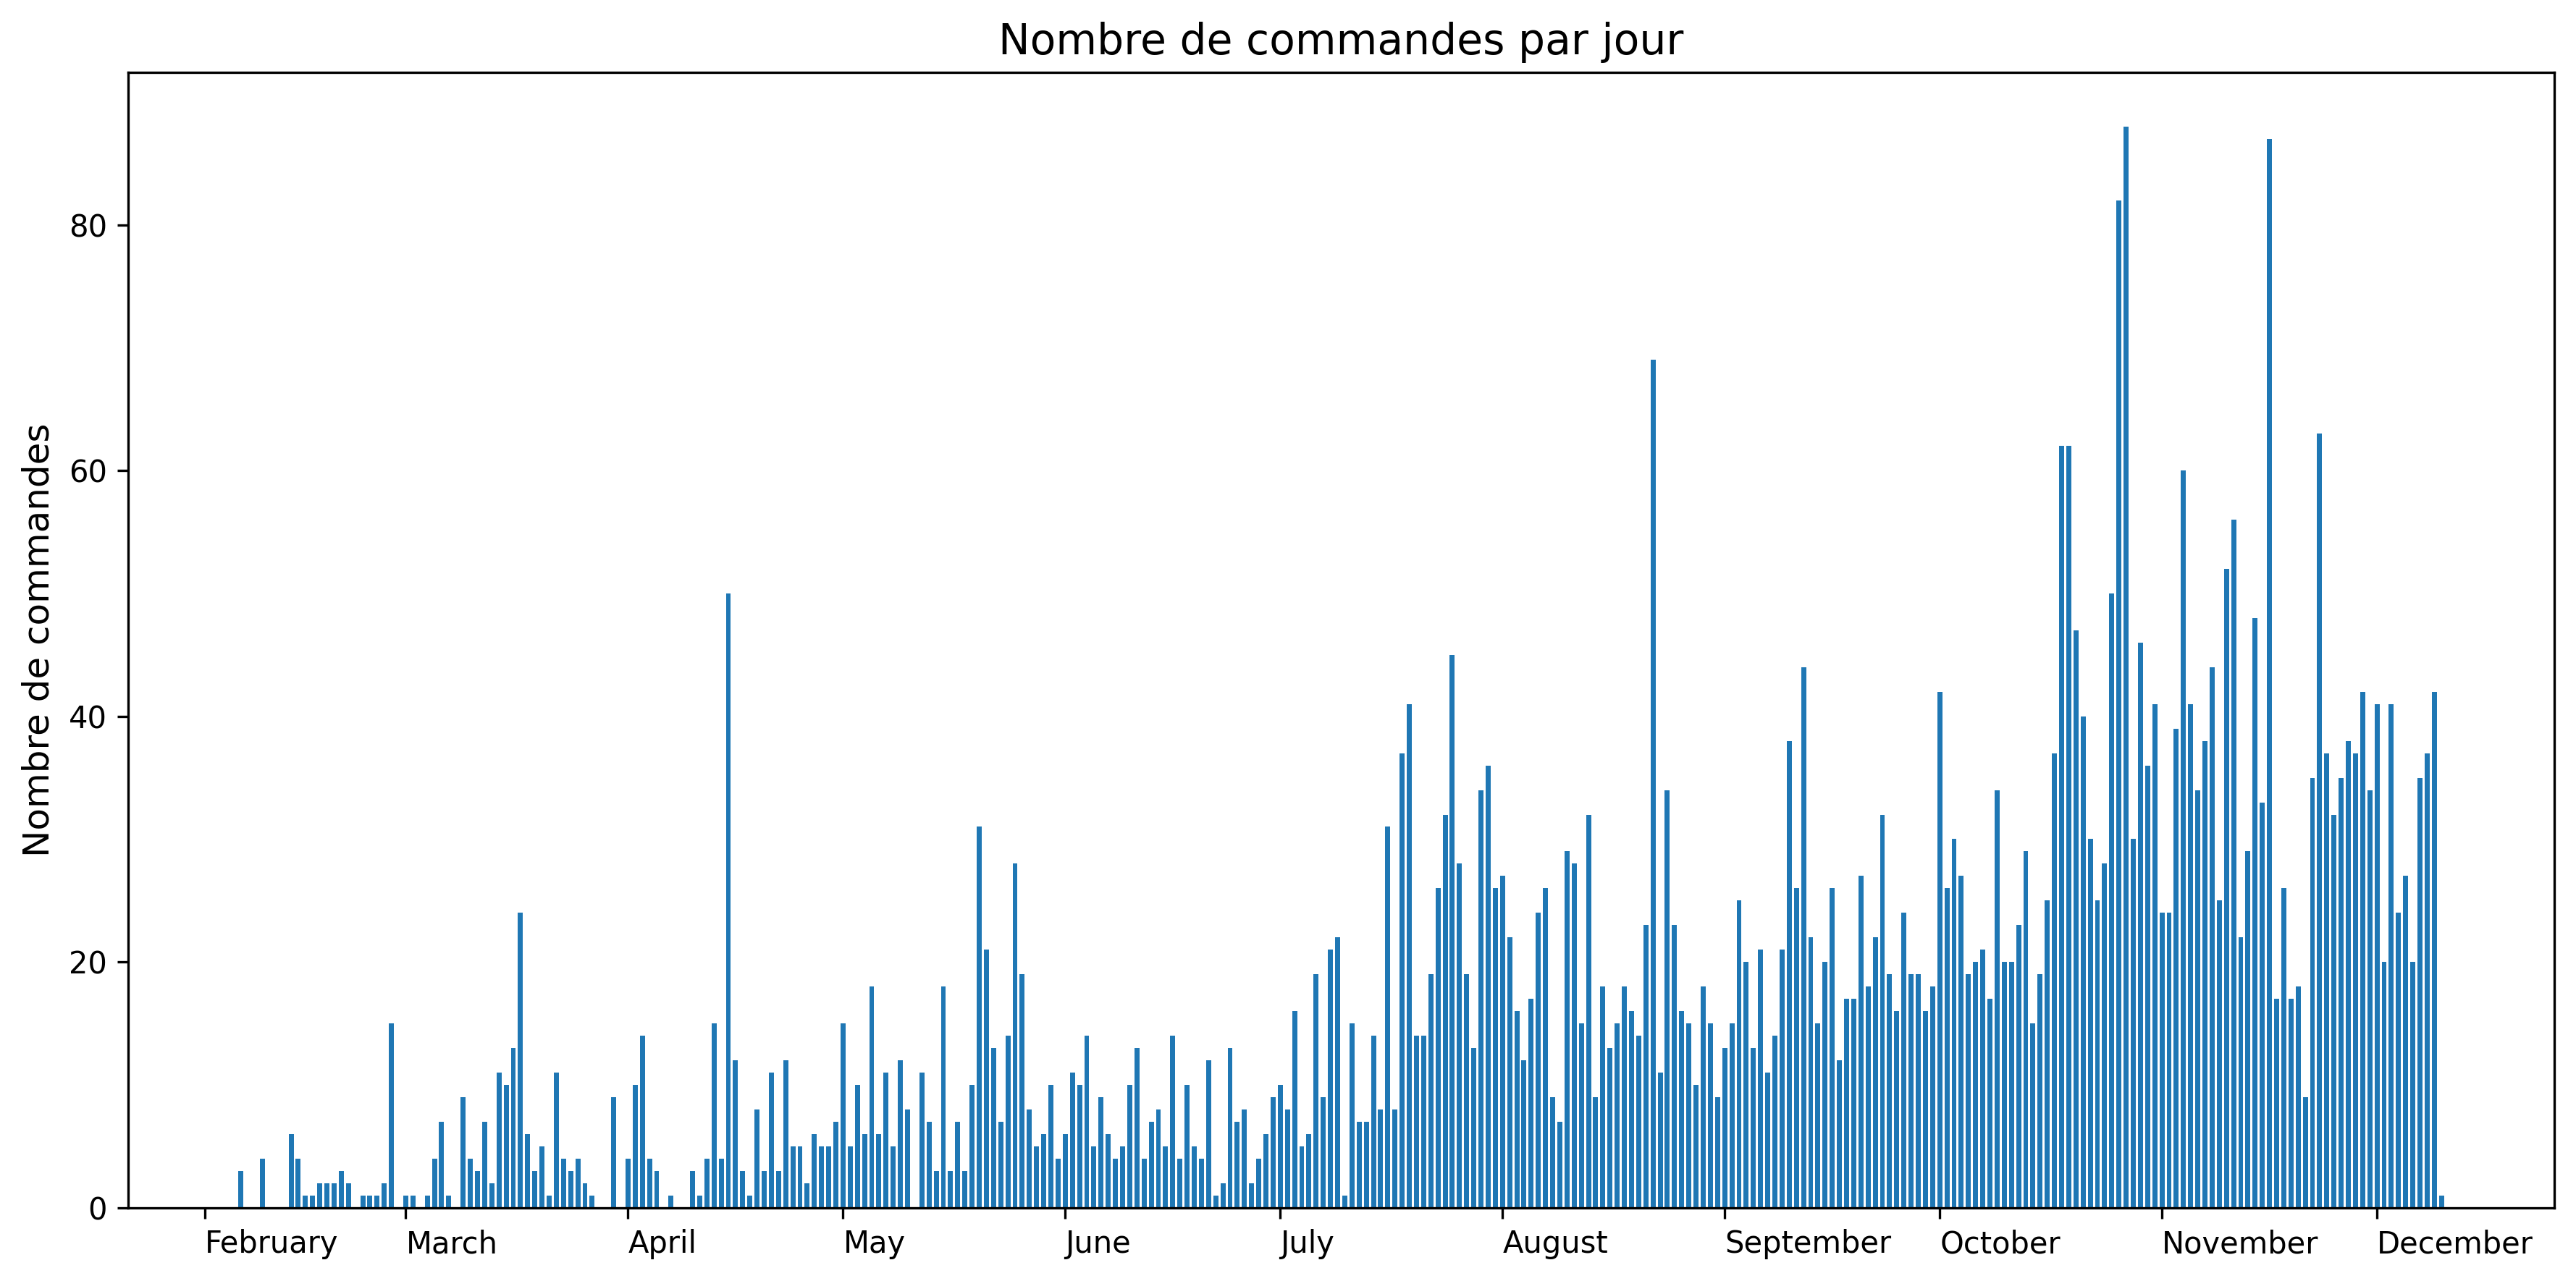

In [9]:
# Assurer que executed_at est bien un datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# --- Par jour ---
logs_per_day = logs_users.groupby(logs_users['executed_at'].dt.date).size()

# --- Par semaine ---
logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
logs_per_week = logs_users.groupby('week').size()

# --- Par mois ---
logs_users['month'] = logs_users['executed_at'].dt.to_period('M')
logs_per_month = logs_users.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.set_title("Number of Commands per Month", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Commands", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%b %y')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()

fig.savefig(img_path+"monthly_commands")
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
###ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




## utilisation des commandes tout le monde

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4148849298.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['week'] = logs['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4148849298.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['month'] = logs['executed_at'].dt.to_period('M')


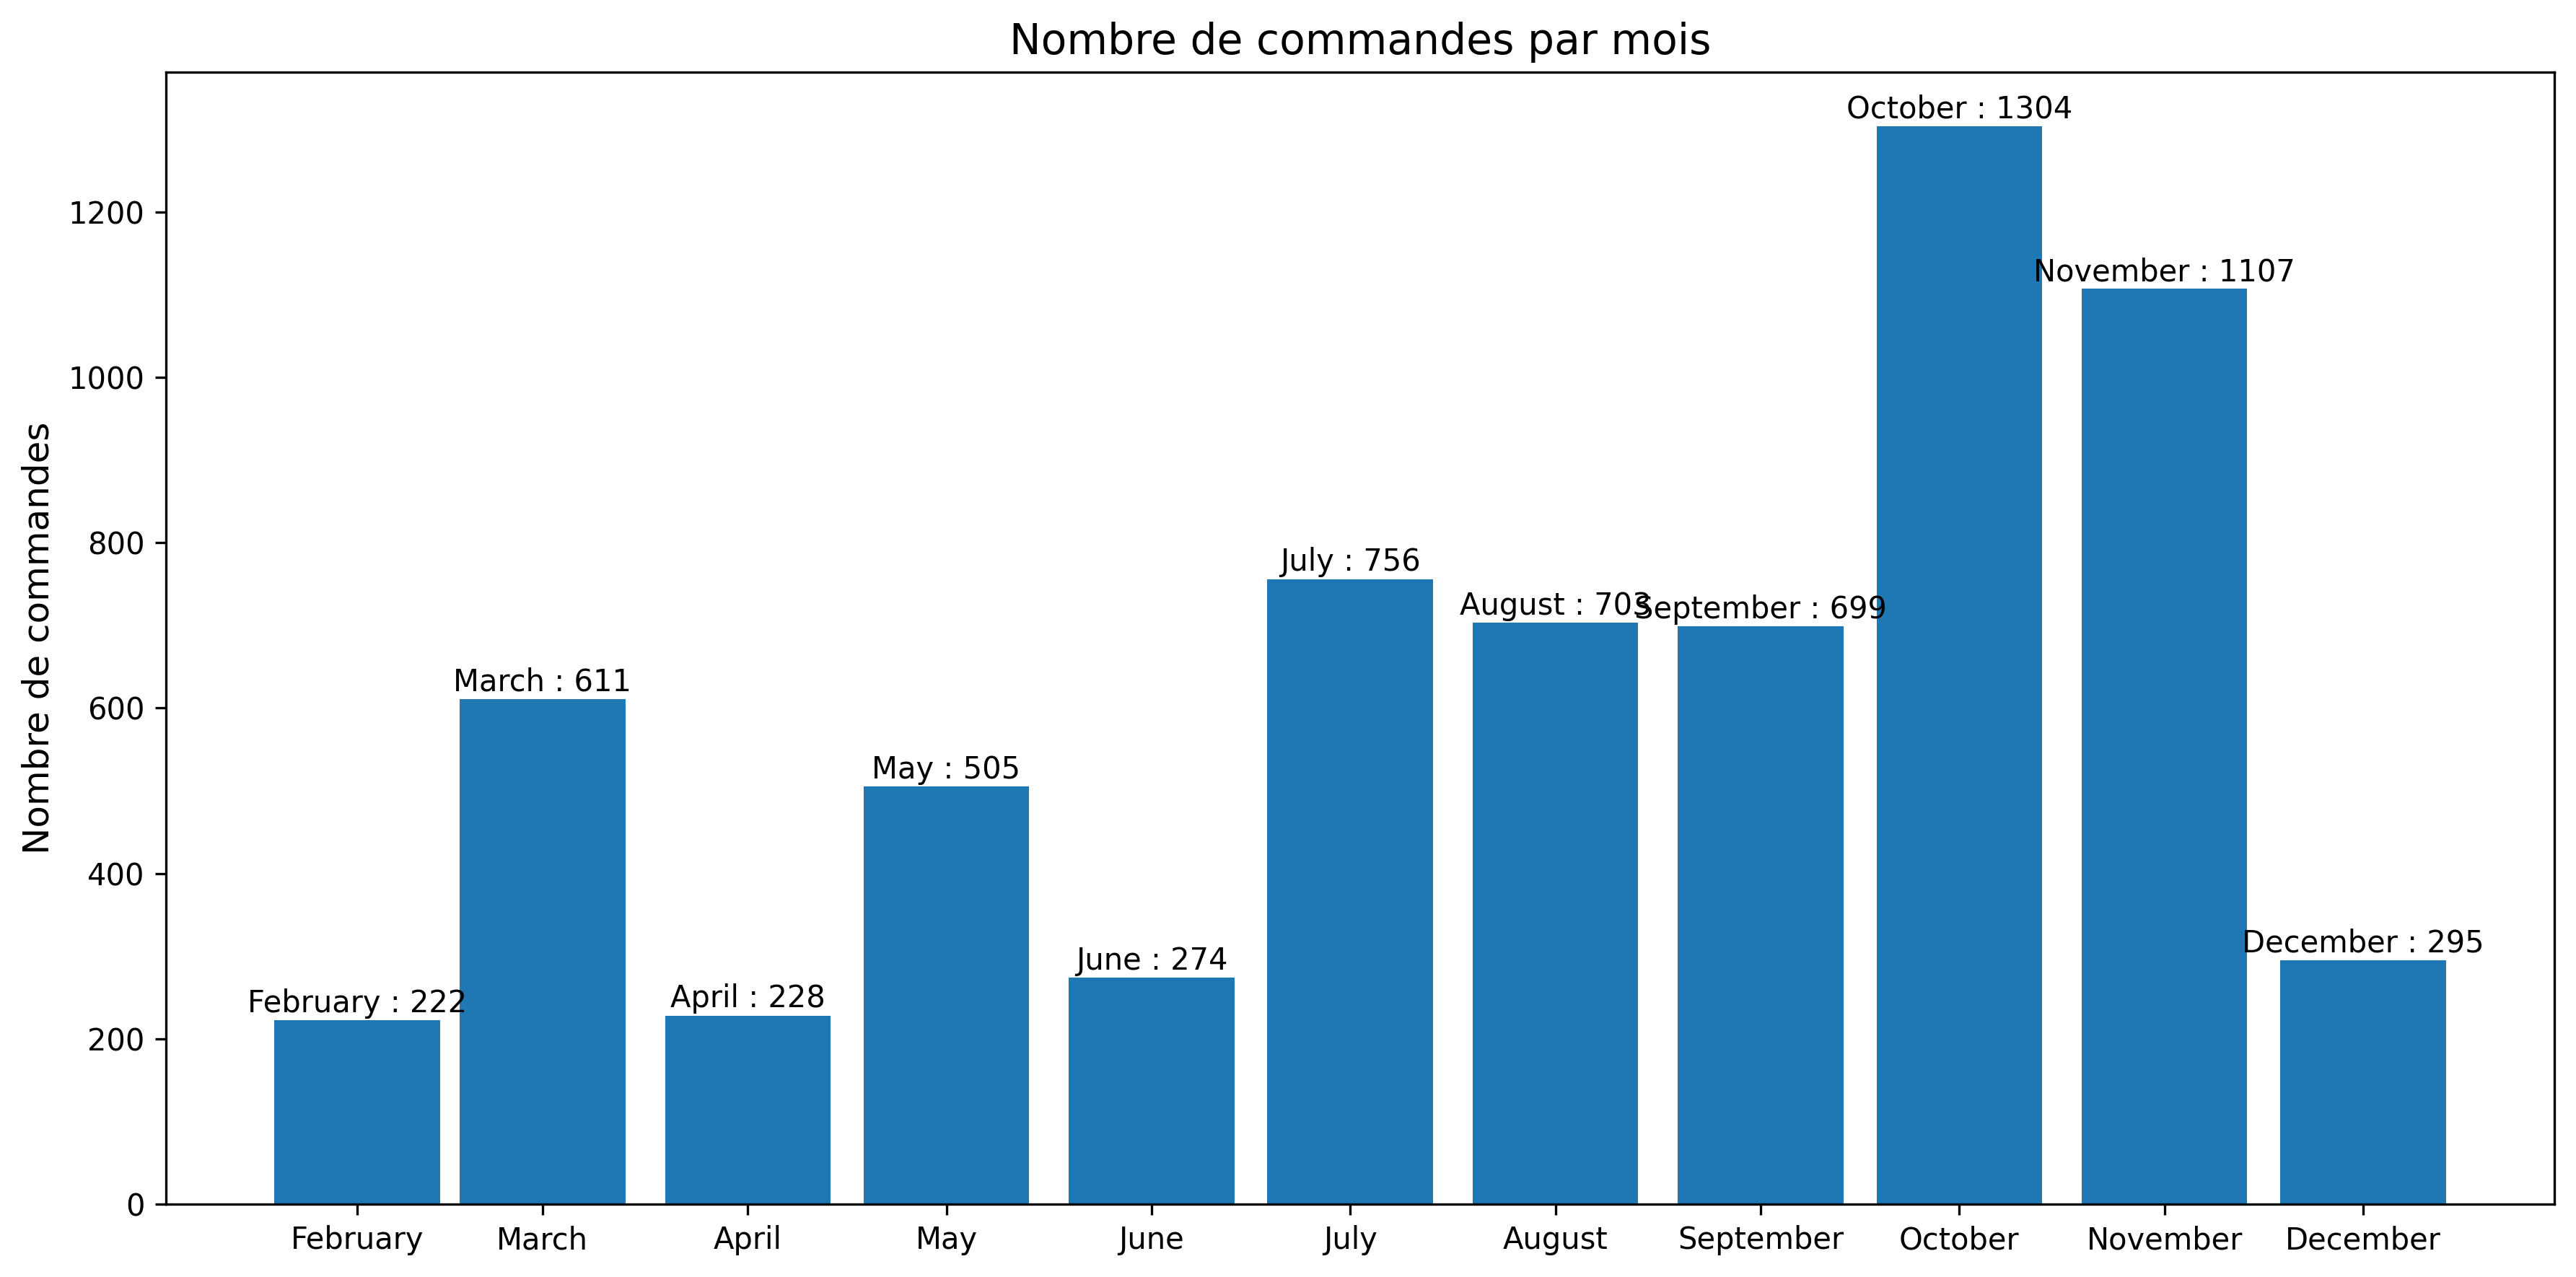

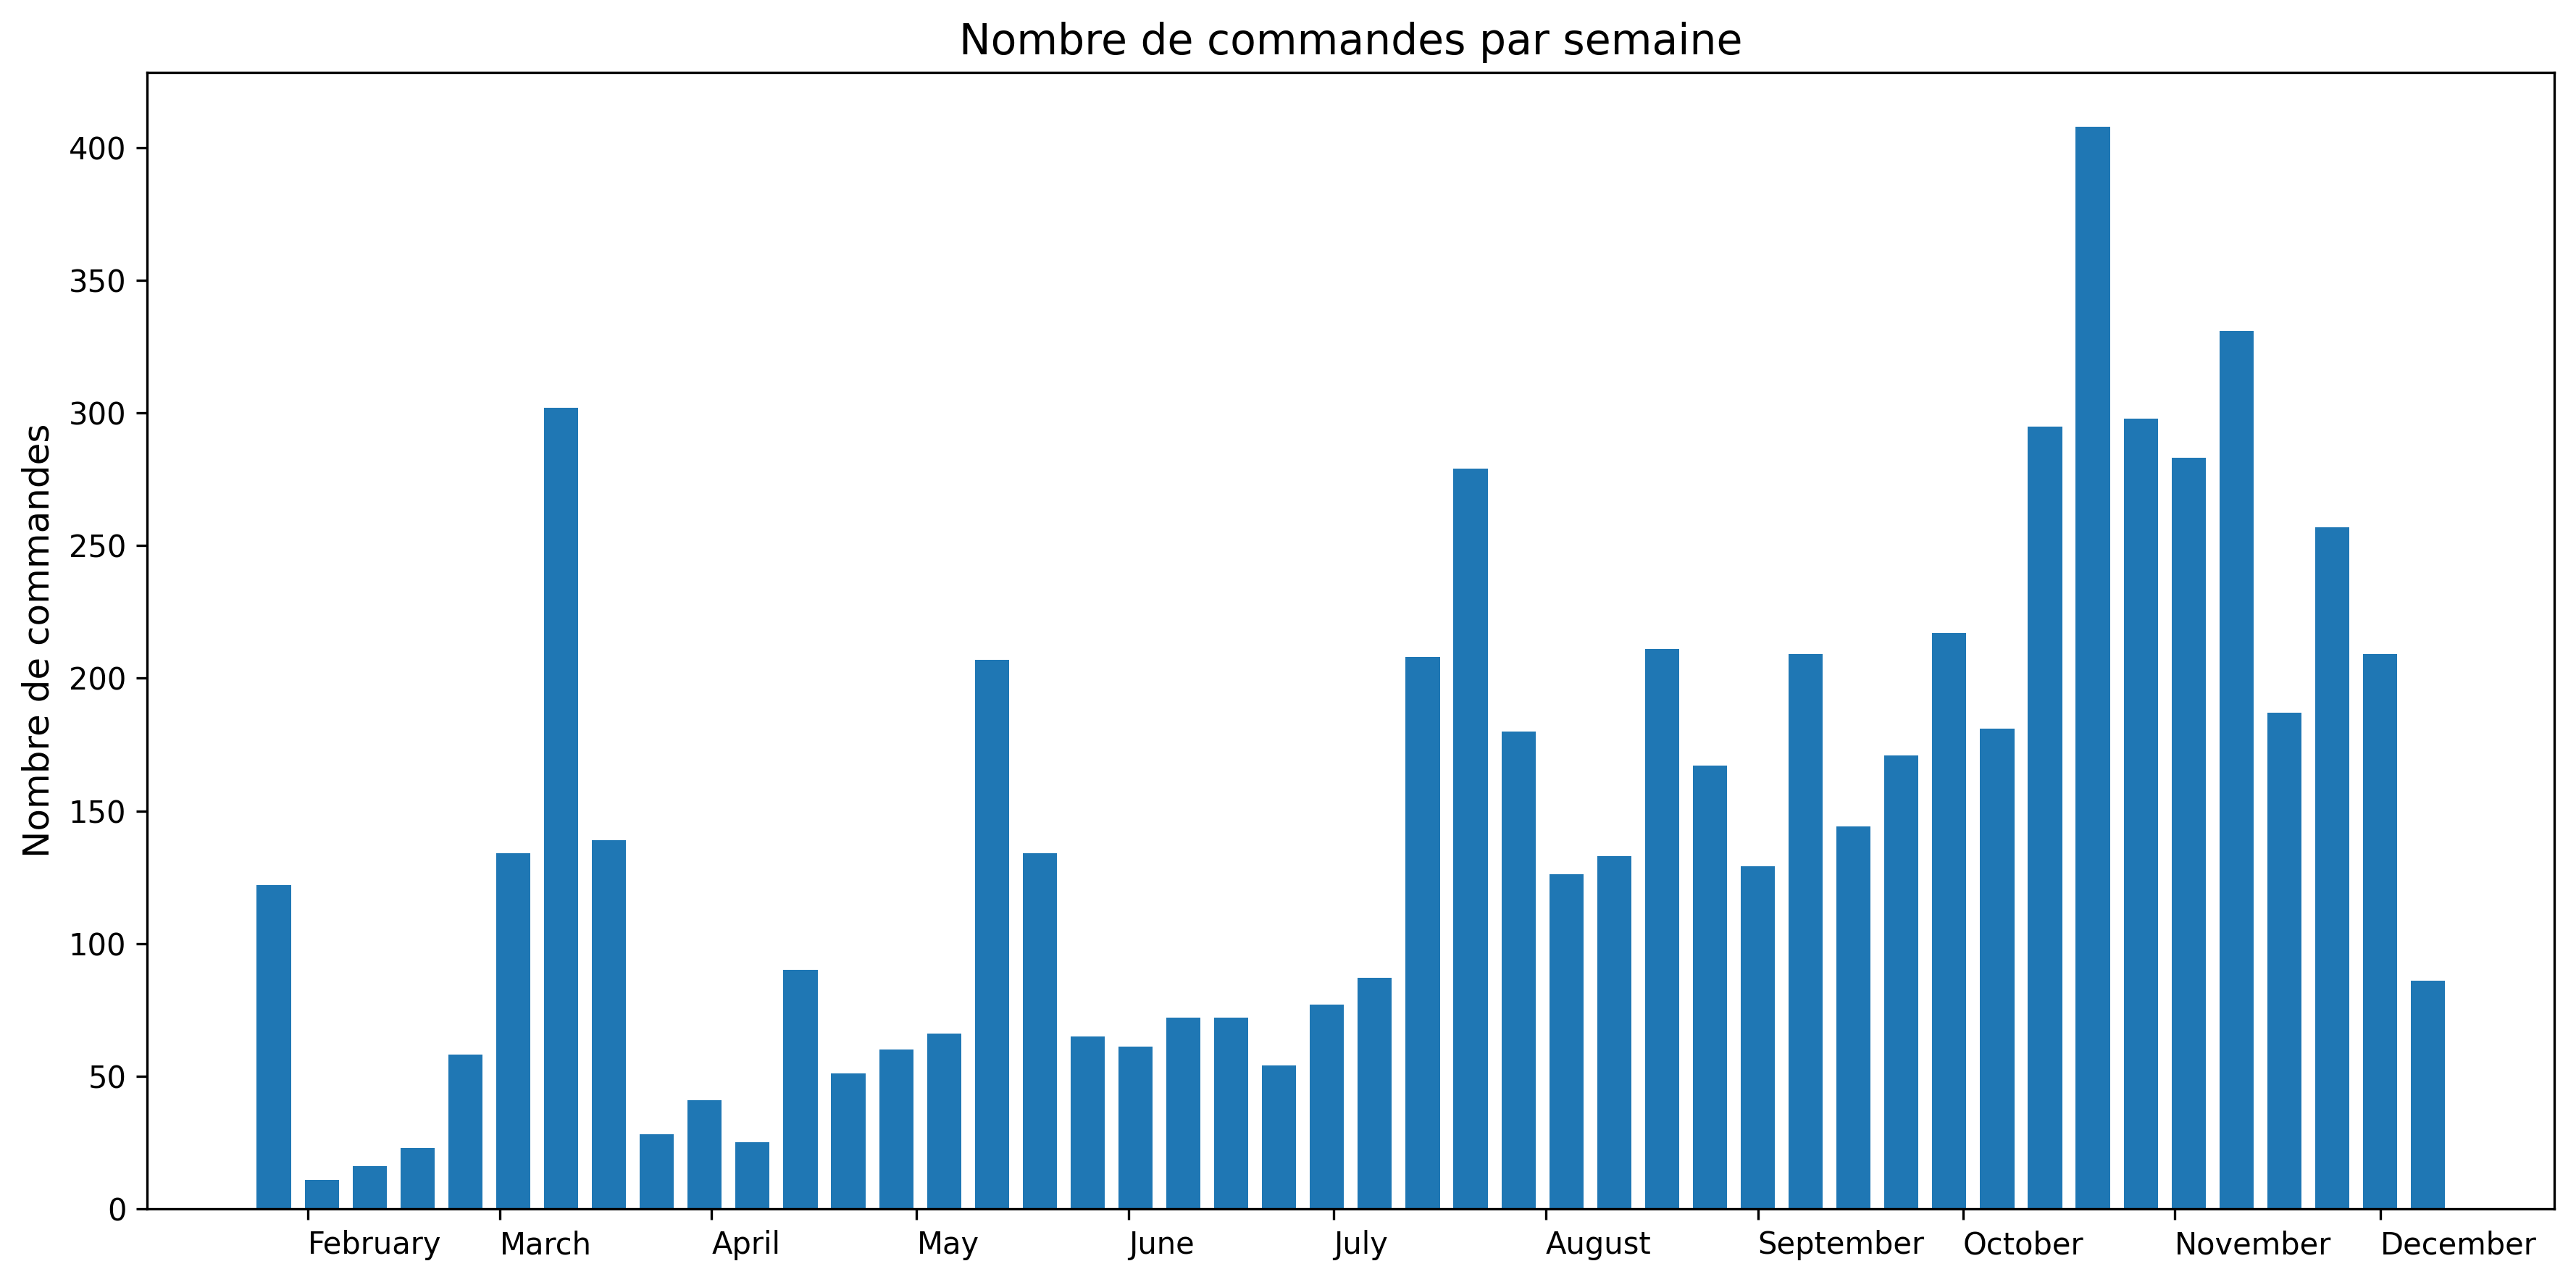

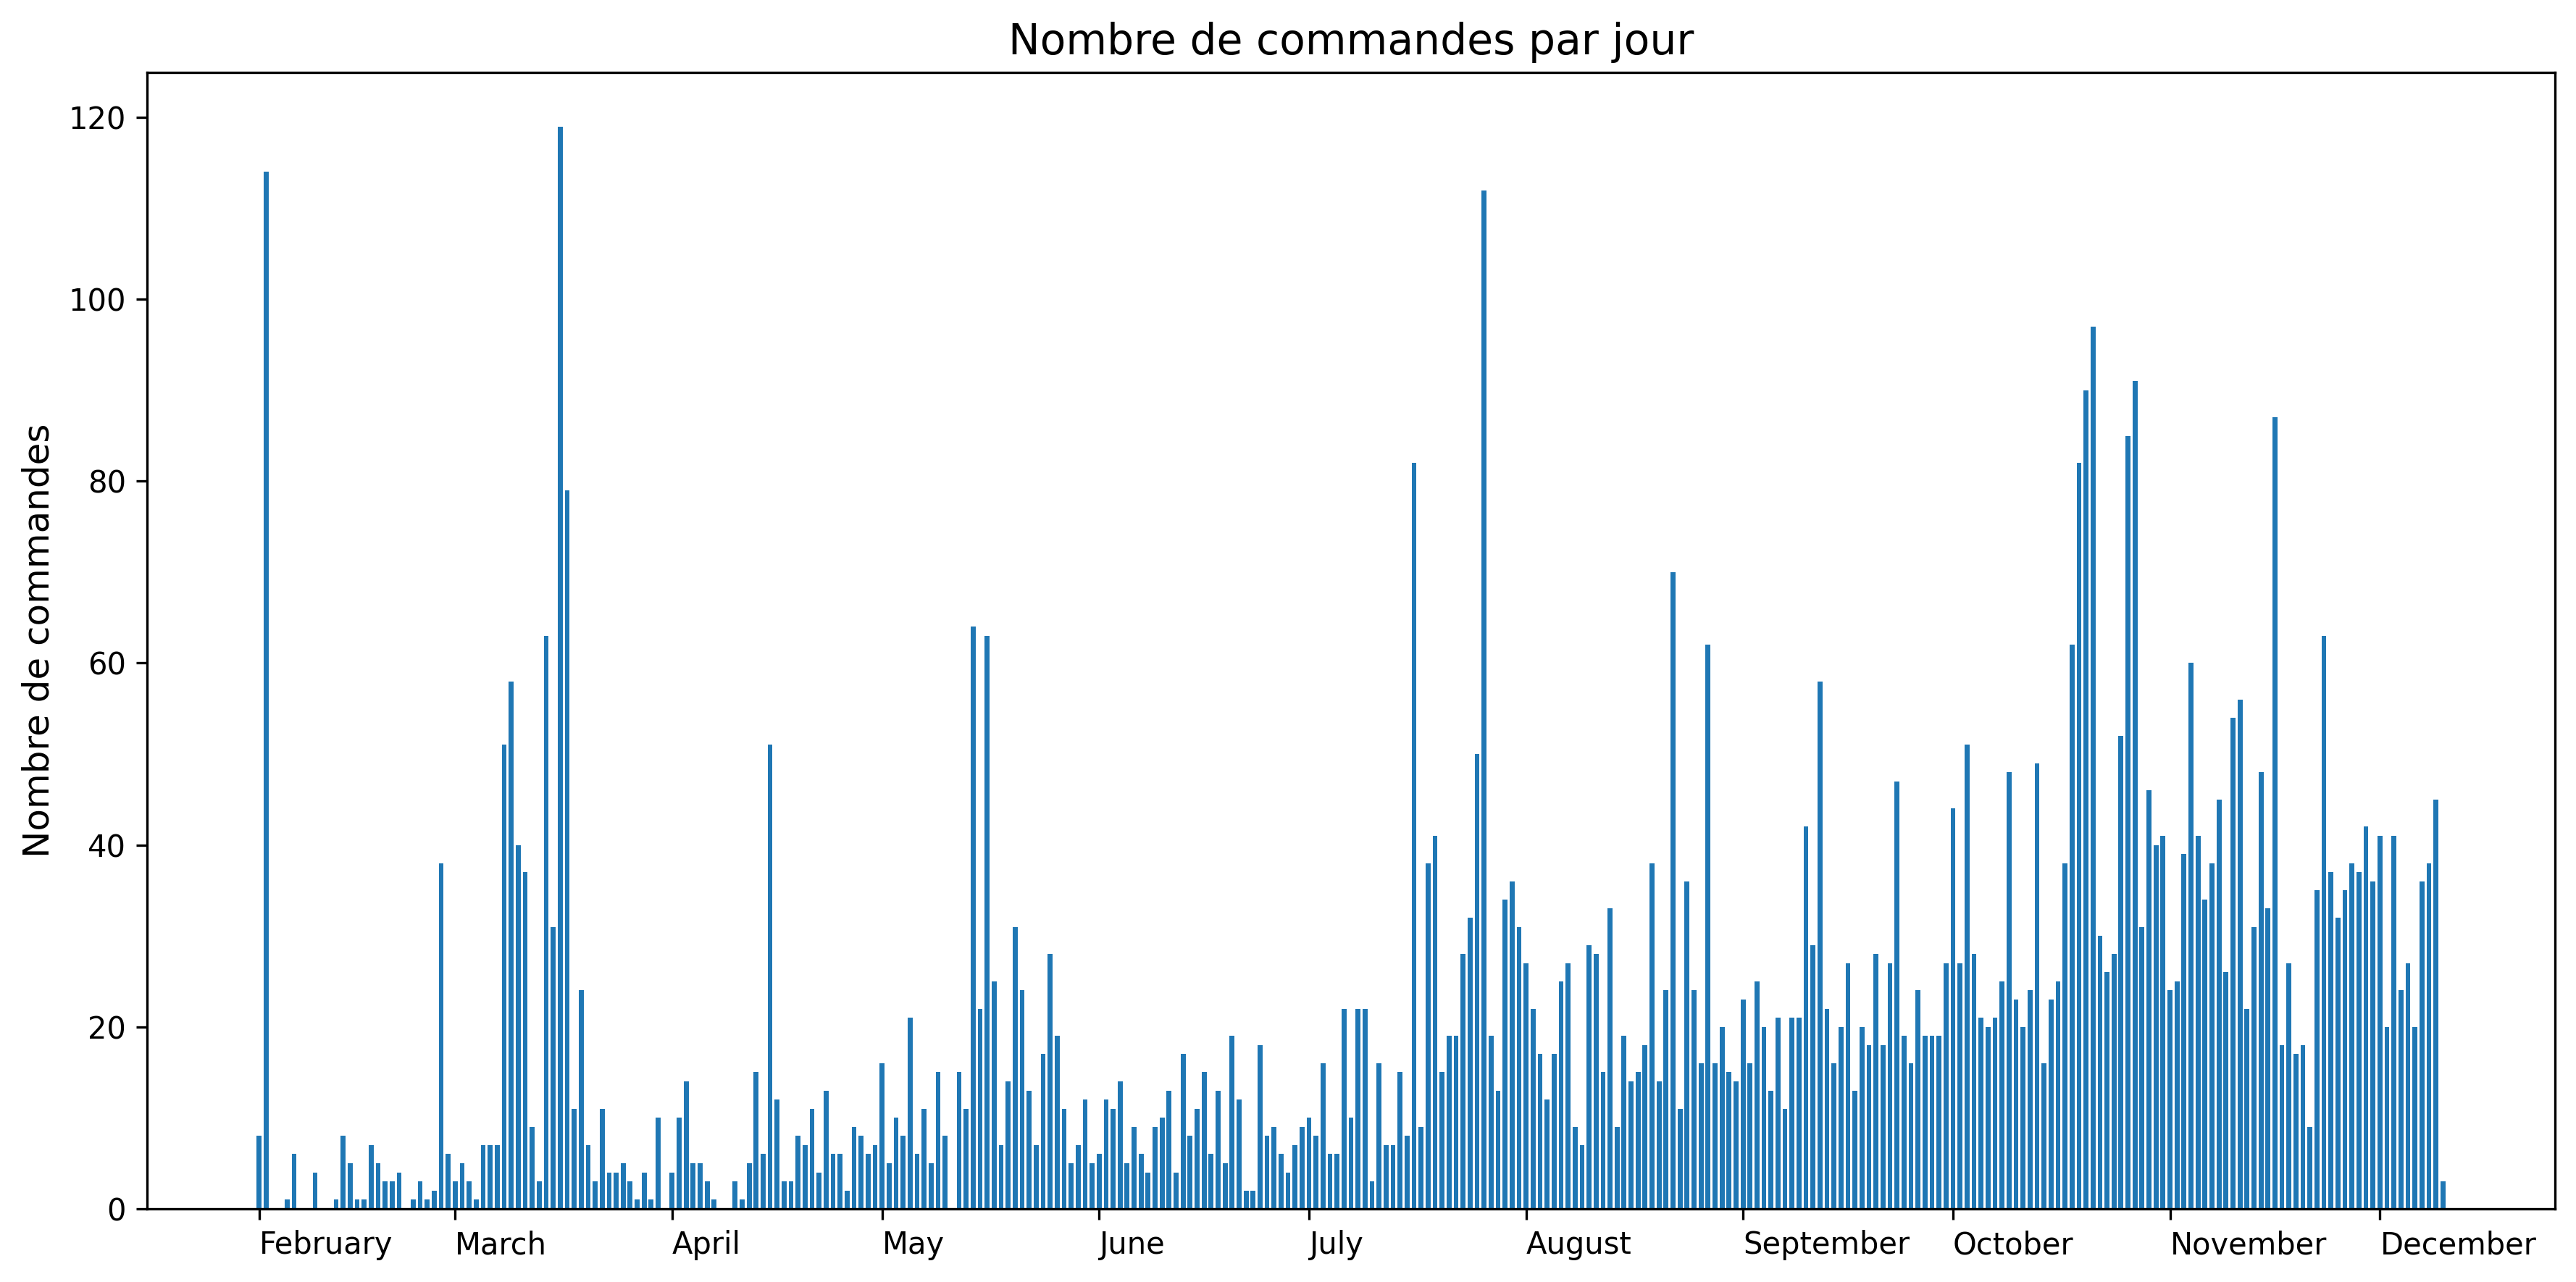

In [10]:

# Assurer que executed_at est bien un datetime
logs['executed_at'] = pd.to_datetime(logs['executed_at'])

# --- Par jour ---
logs_per_day = logs.groupby(logs['executed_at'].dt.date).size()

# --- Par semaine ---
logs['week'] = logs['executed_at'].dt.to_period('W')
logs_per_week = logs.groupby('week').size()

# --- Par mois ---
logs['month'] = logs['executed_at'].dt.to_period('M')
logs_per_month = logs.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()





## utilisation des commandes warp

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\1793532722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\1793532722.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\1793532722.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

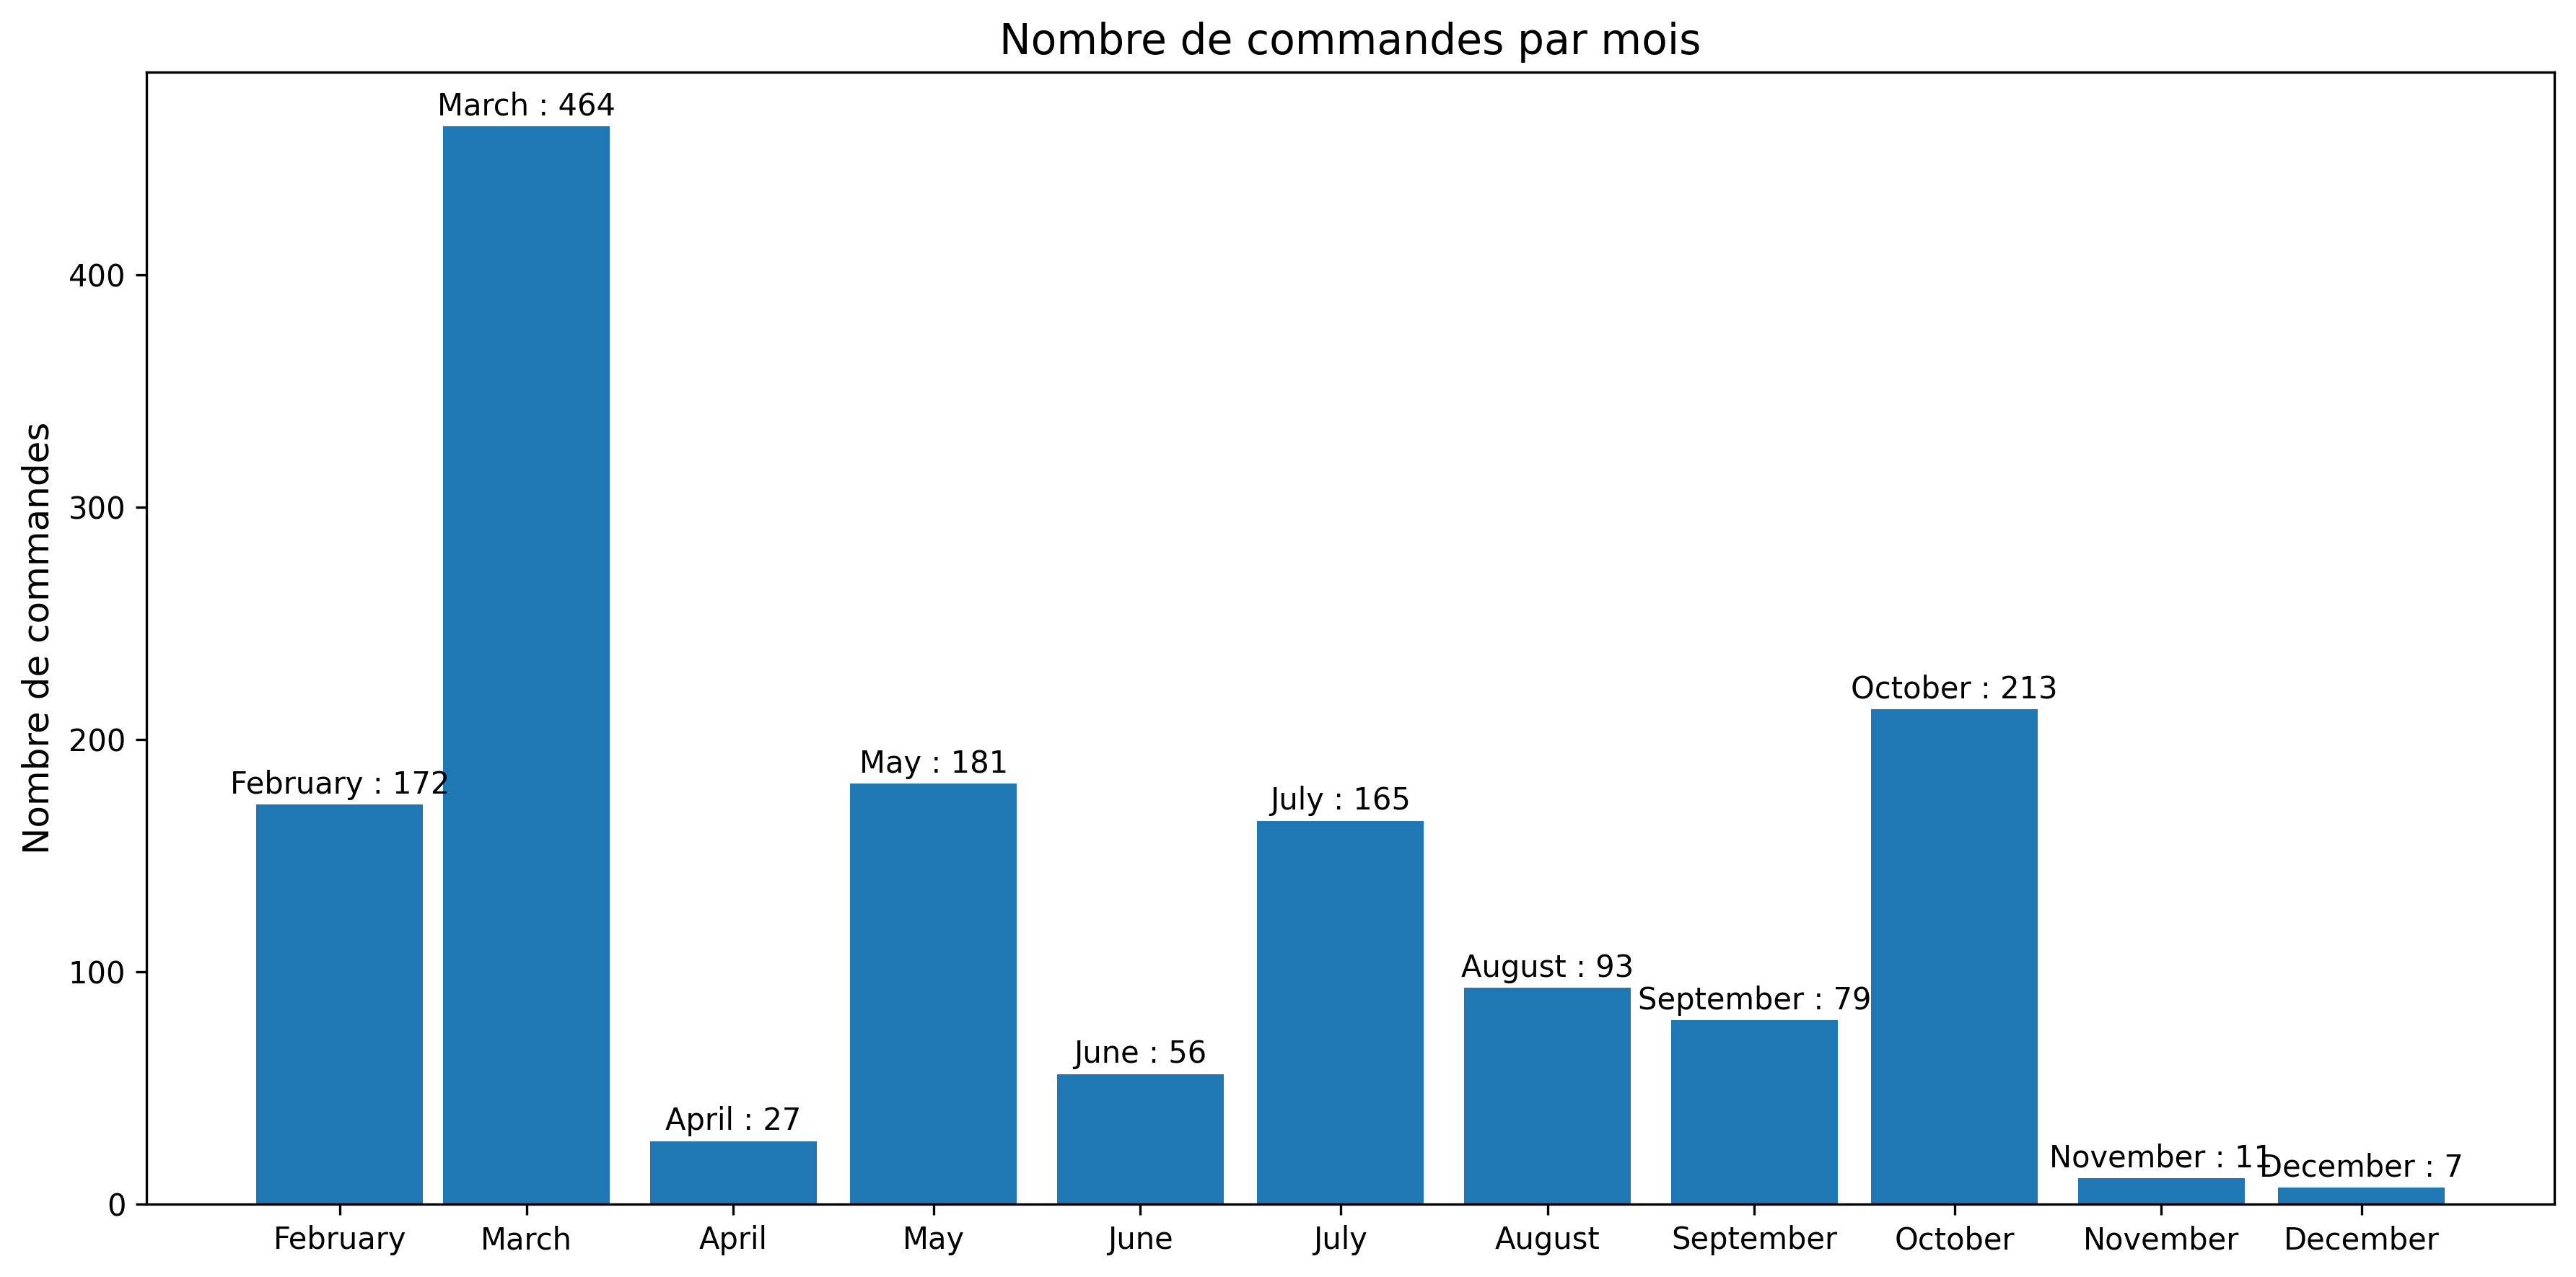

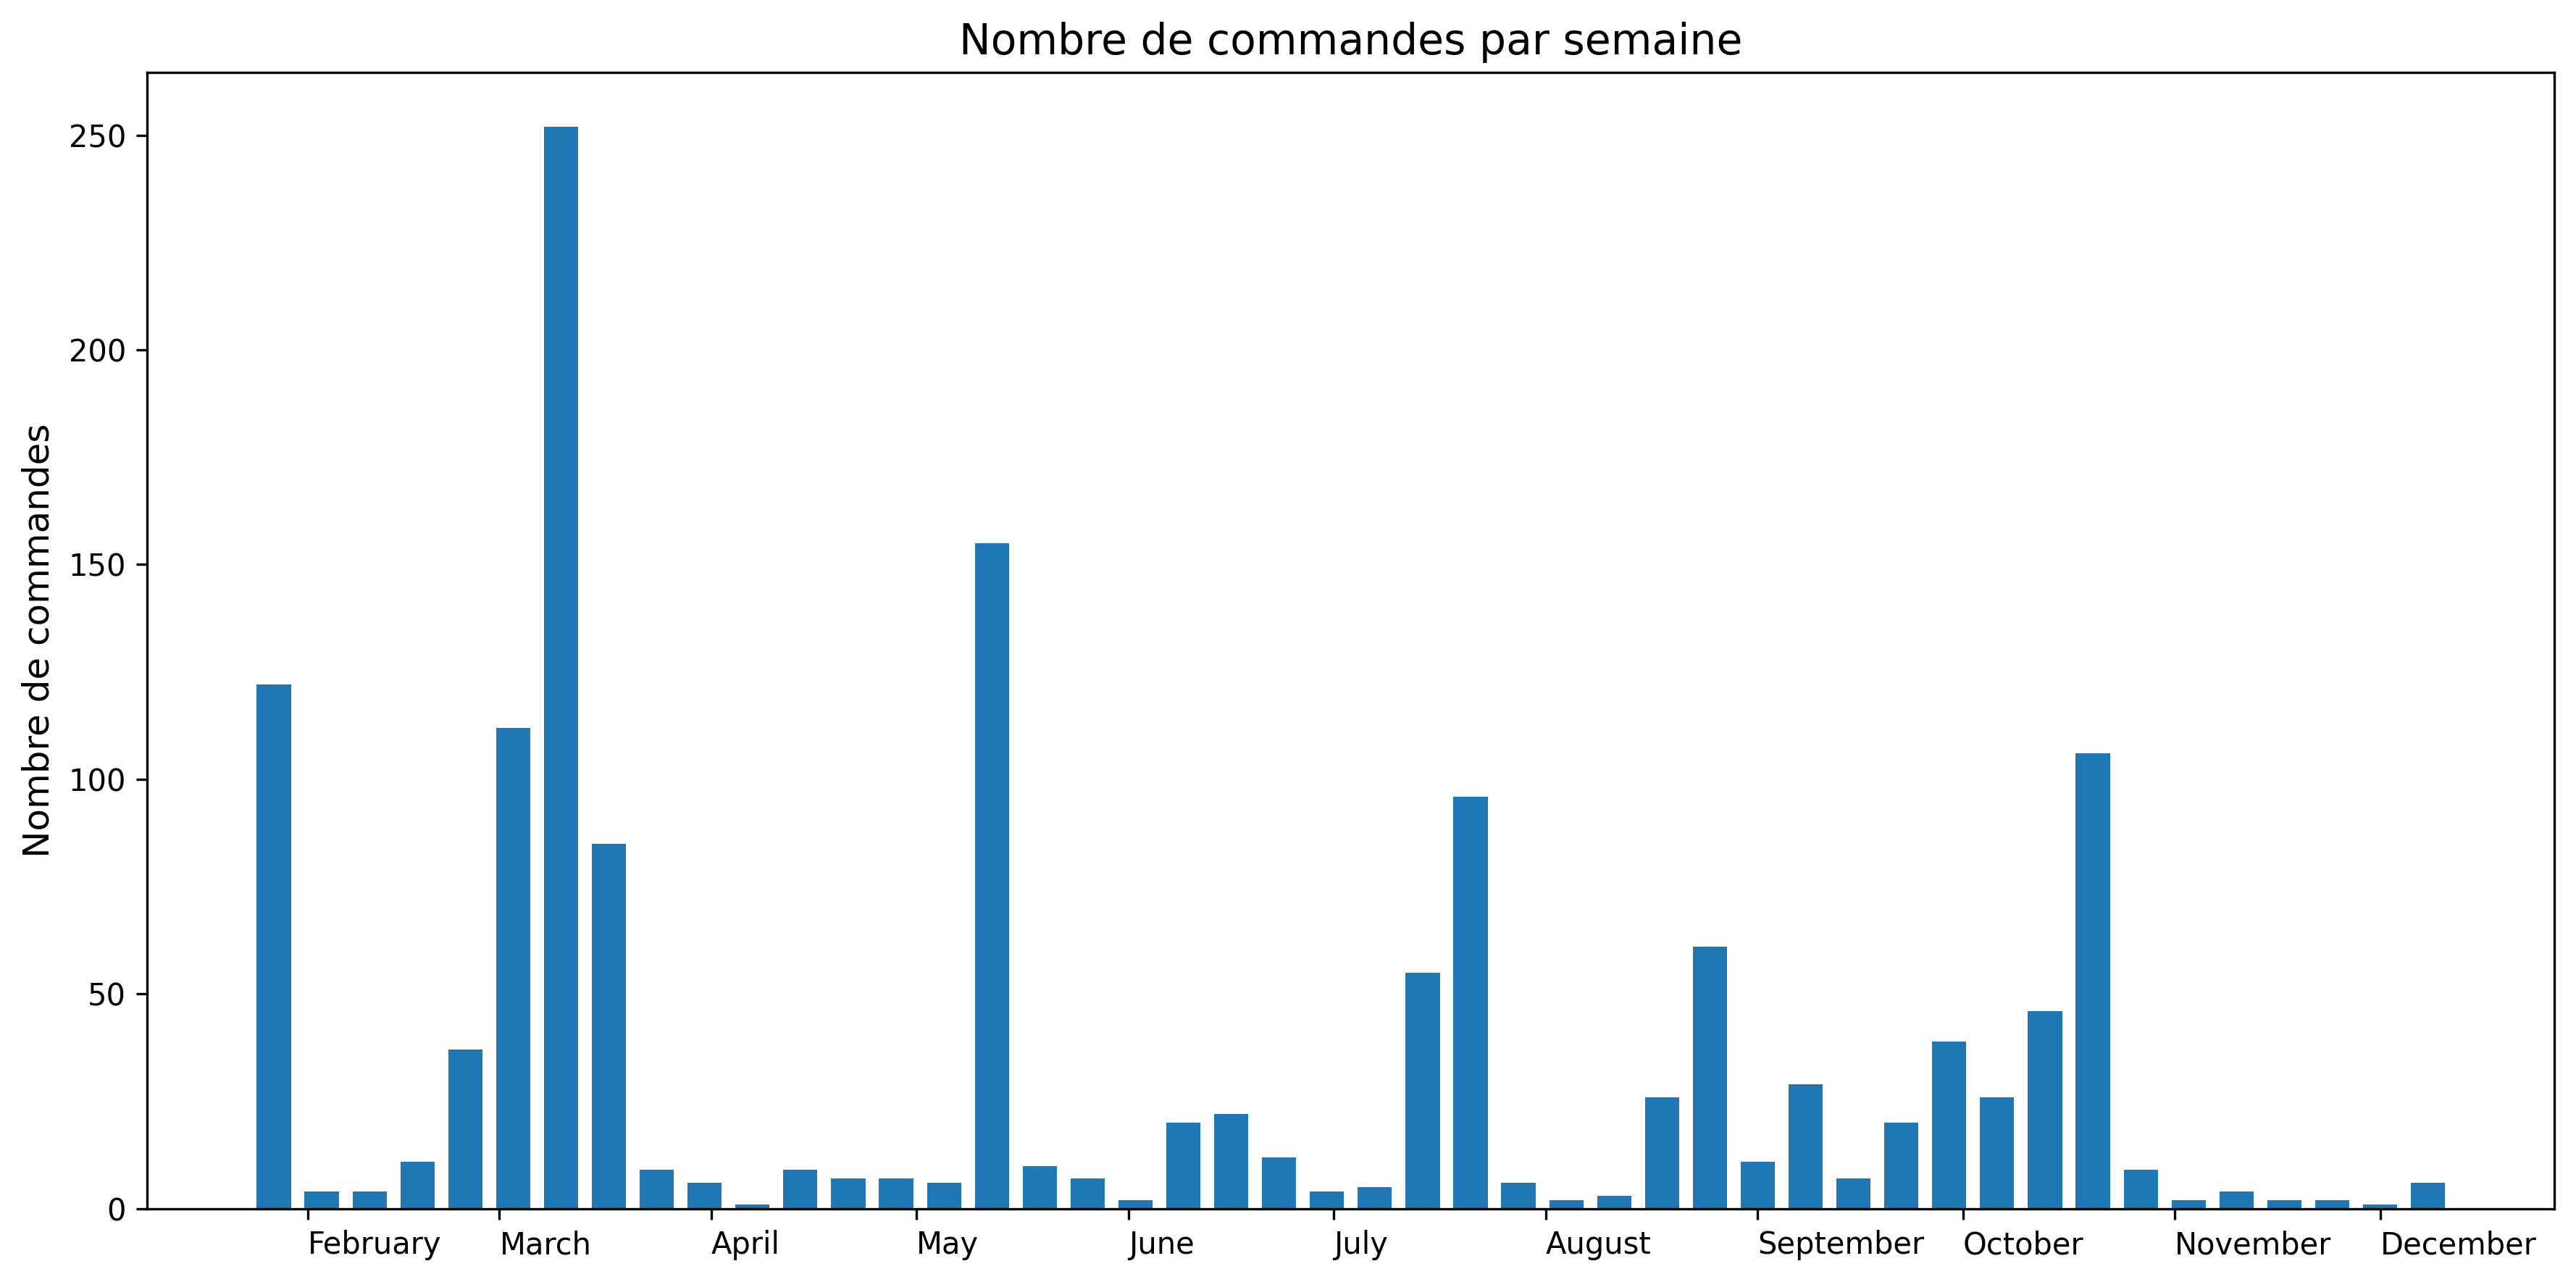

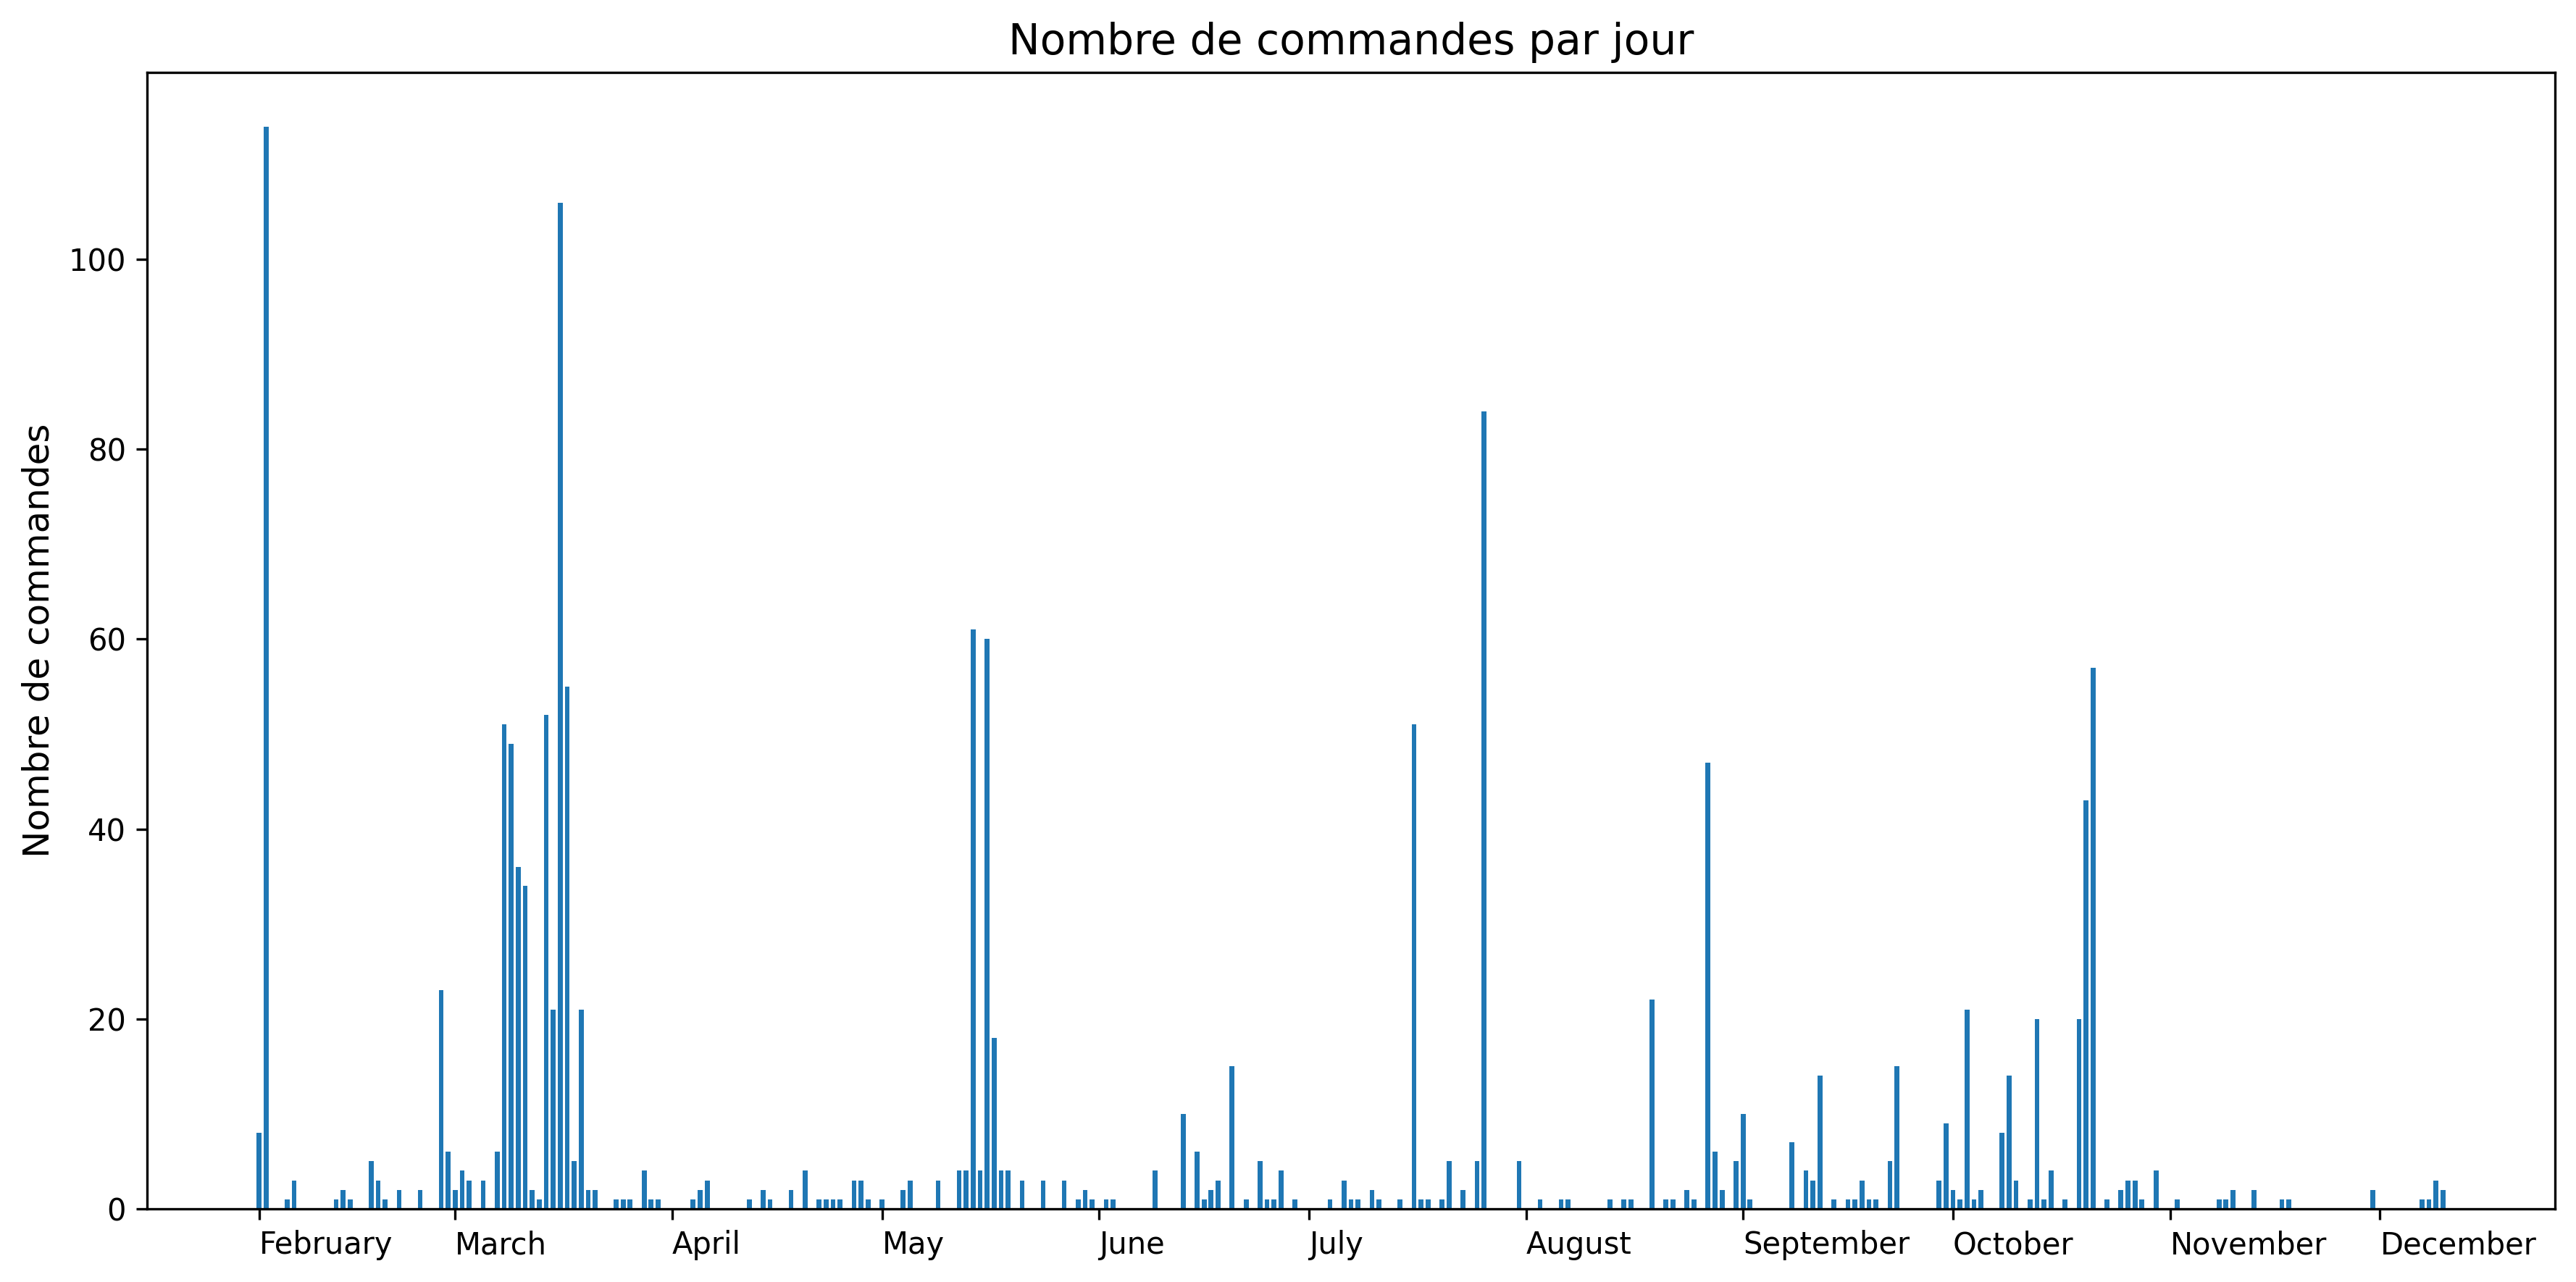

In [11]:

# Assurer que executed_at est bien un datetime
logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])

# --- Par jour ---
logs_per_day = logs_warp.groupby(logs_warp['executed_at'].dt.date).size()

# --- Par semaine ---
logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
logs_per_week = logs_warp.groupby('week').size()

# --- Par mois ---
logs_warp['month'] = logs_warp['executed_at'].dt.to_period('M')
logs_per_month = logs_warp.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




# nombre de serveurs et utilisateurs ayant >3 commandes

In [12]:
logs_per_user = logs_users.groupby("user_name")["id"].count().sort_values(ascending=False)
print("nombre d'utilisateurs :",len(logs_per_user))
print("nombre d'utilisateurs ayant fait plus de 3 commandes :",len([logs_per_user.index[i] for i in range(len(logs_per_user)) if logs_per_user.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_user.iloc[:10].index:
    nb_cmd=logs_per_user[usr]
    print(f" - {rang}. @{usr} : {nb_cmd}")
    rang+=1
    

nombre d'utilisateurs : 754
nombre d'utilisateurs ayant fait plus de 3 commandes : 378
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. @ilydan : 120
 - 2. @joao1784 : 76
 - 3. @.grybz : 65
 - 4. @adzm95 : 62
 - 5. @klaudrr : 61
 - 6. @kymoh_ : 53
 - 7. @presquepopof : 52
 - 8. @timeo6026 : 49
 - 9. @cedp : 49
 - 10. @shurik0810 : 47


In [13]:
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
print("nombre de serveurs :",len(logs_per_server))
print("nombre de serveurs ayant fait plus de 3 commandes :",len([logs_per_server.index[i] for i in range(len(logs_per_server)) if logs_per_server.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_server.iloc[:10].index:
    nb_cmd=logs_per_server[usr]
    print(f" - {rang}. {usr} : {nb_cmd}")
    rang+=1

nombre de serveurs : 147
nombre de serveurs ayant fait plus de 3 commandes : 108
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. Dofus Touls : 679
 - 2. La Secte : 526
 - 3. Origami : 248
 - 4. Stellar - Dofus TOUCH : 243
 - 5. Nouveau Règne [NRV] : 211
 - 6. Tchiki-tchiki : 142
 - 7. H O N O R E D : 139
 - 8. Horizon : 135
 - 9. Katoa : 116
 - 10. Maarss Community : 114


In [14]:

def get_contrast_color(rgba):
    """
    Retourne 'white' ou 'black' selon la luminosité de la couleur RGBA.
    """
    r, g, b, _ = rgba
    # Luminosité perçue
    brightness = 0.299*r + 0.587*g + 0.114*b
    return 'white' if brightness < 0.5 else 'black'

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 129680 (\N{RINGED PLANET}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 3663 (\N{THAI CHARACTER FONGMAN}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 65314 (\N{FULLWIDTH LATIN CAPITAL LETTER B}) missing from current font.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4237021991.py:100: UserWarning: Glyph 65317 (\N{FULLWIDTH LATIN CAPITAL LETTER E}) missing from current 

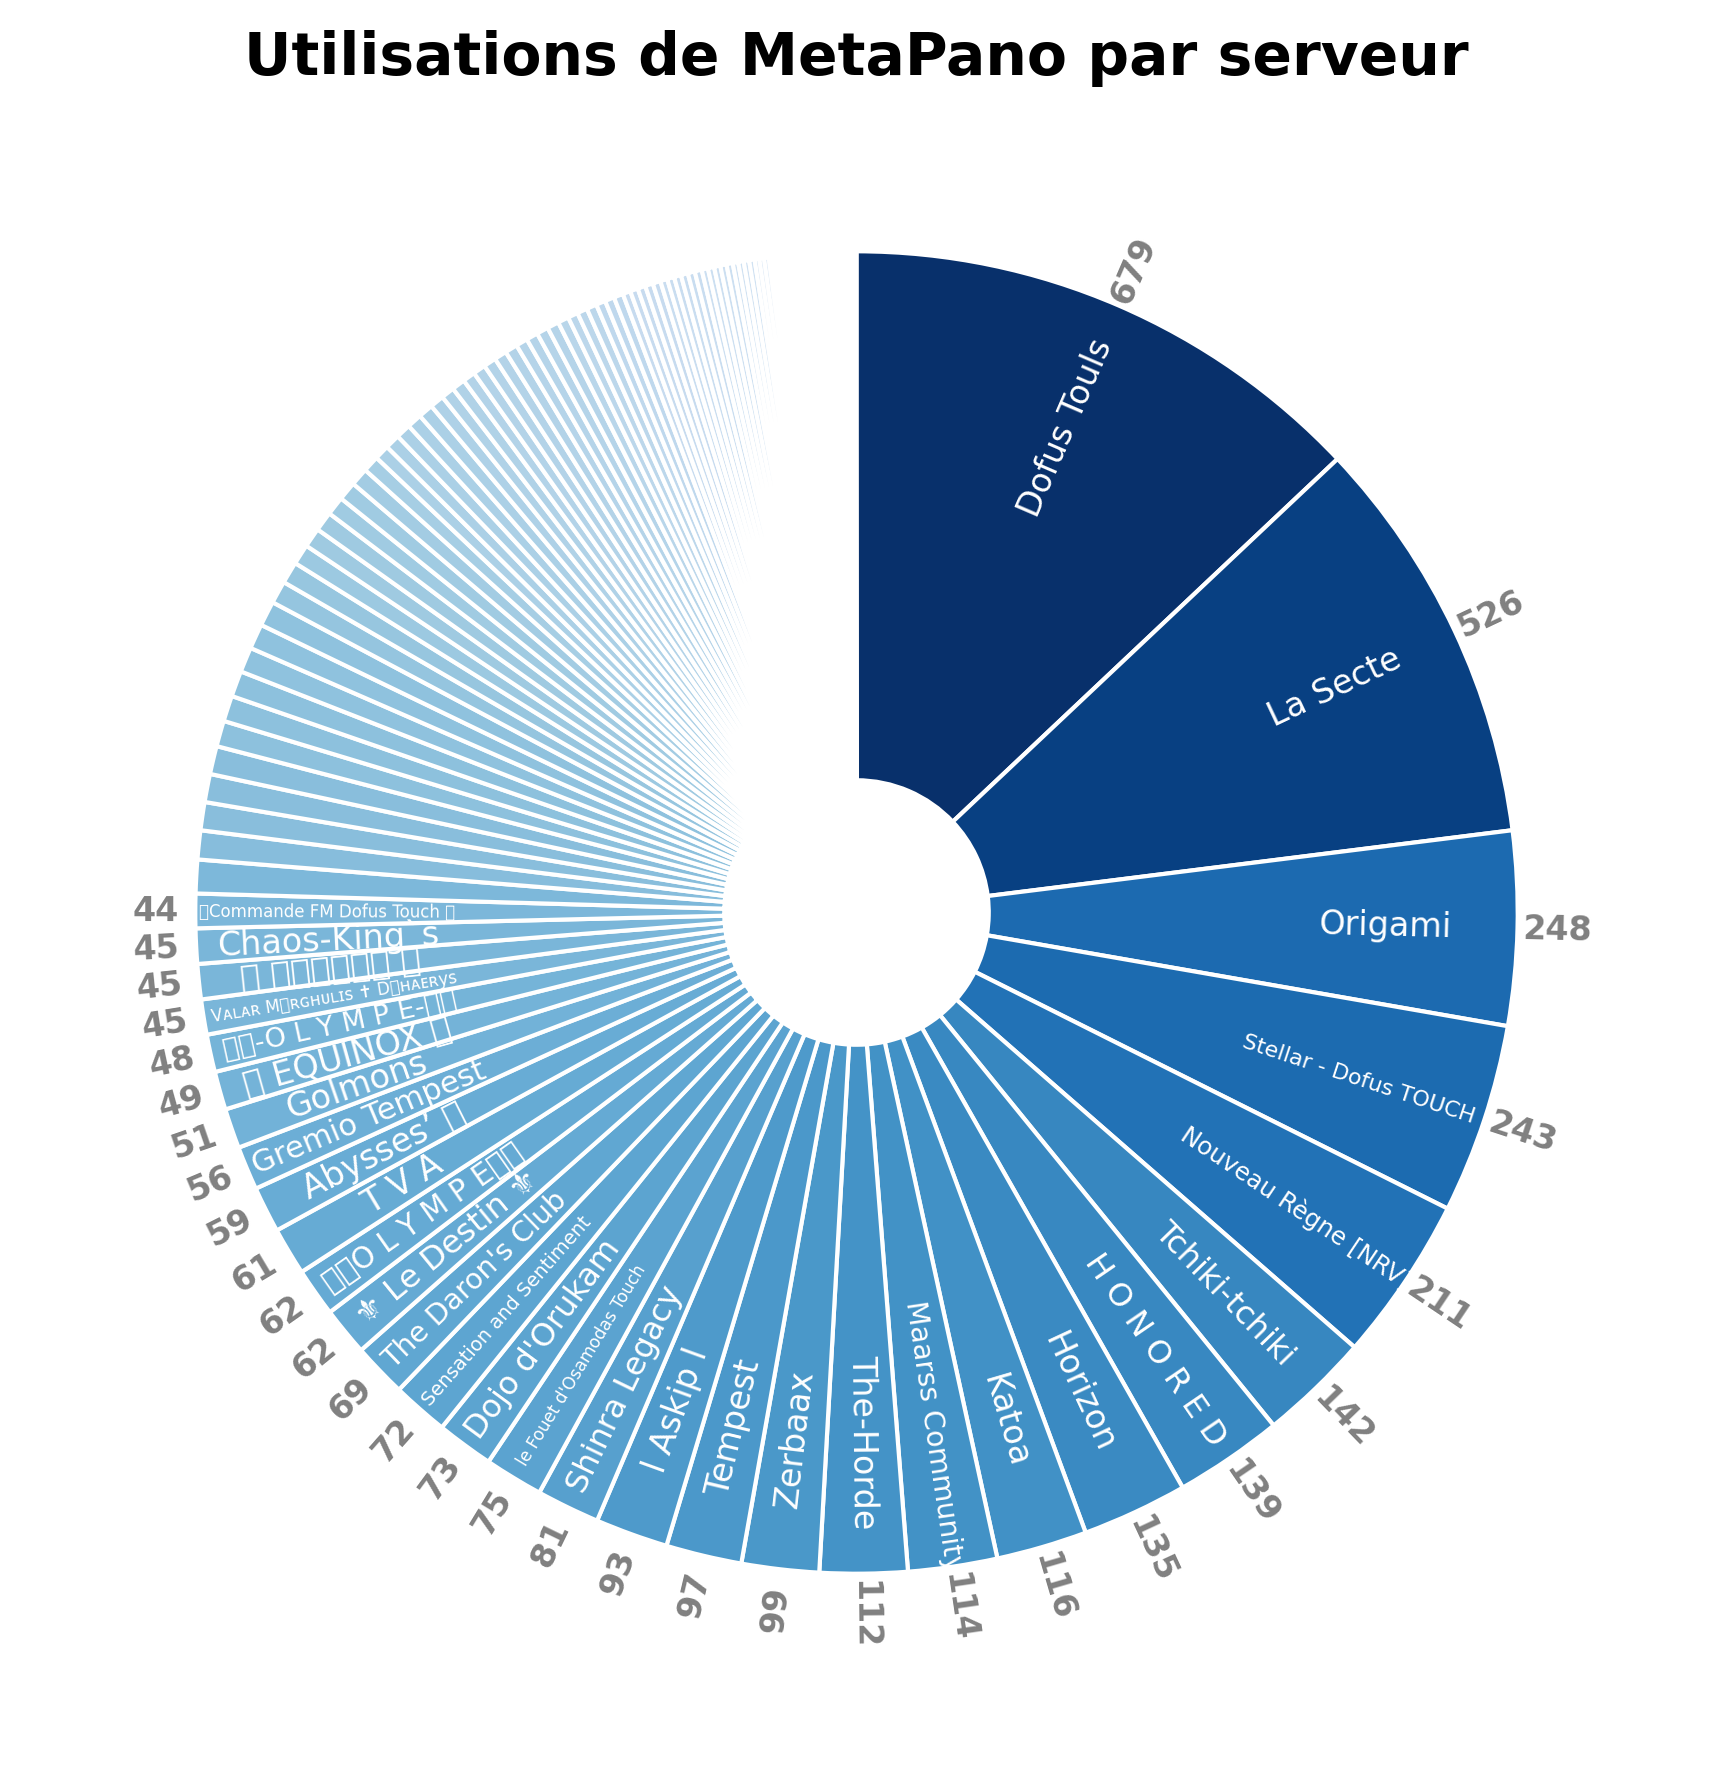

In [15]:
nb_noms_affichés=15
nb_parts=len(logs_per_server)
# colors = cm.plasma(np.linspace(0.4, 1, nb_parts))  # 0.4 évite les couleurs trop claires
# fig, ax= plt.subplots(figsize=(12,12),dpi=300)
# ax.pie(logs_per_server.iloc[:100],labels=logs_per_server.iloc[:nb_noms_affichés].index.to_list()+[""]*(nb_parts-nb_noms_affichés))

# # ----- Dégradé logarithmique -----
# log_values = np.log1p(logs_per_server.values)  # log(1 + x) pour éviter log(0)
# norm = (log_values - log_values.min()) / (log_values.max() - log_values.min())
# colors = cm.Blues(norm)    # Version 1 : dégradé logarithmique (bleu)

# ----- Dégradé racine carrée -----
# scaled_values = np.sqrt(logs_per_server.values)
# norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
# colors = cm.Blues(norm)  # ou cm.Blues_r pour inverser

# ----- Dégradé puissance perso -----
alpha = 0.15  # Plus petit = plus doux, 1 = linéaire
scaled_values = np.power(logs_per_server.values, alpha)
norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
colors = cm.Blues(norm)


available_colormaps = [
    cm.viridis,cm.viridis_r, cm.plasma,cm.plasma_r, cm.inferno, cm.inferno_r, cm.magma,cm.magma_r,
    cm.cividis,cm.cividis_r, cm.Blues, cm.Blues_r, cm.Reds, cm.Greens, cm.Purples
]
colors_list=[]
for c in available_colormaps:
    colors_list.append(c(norm))

# ===== Données =====
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
values = logs_per_server.values
labels = logs_per_server.index

# ----- Fonction pour dessiner le pie chart -----
def plot_pie(data, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    wedges, _ = ax.pie(
        data,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.8, edgecolor='white')
    )

    for i, wedge in enumerate(wedges):        
        theta1, theta2 = wedge.theta1, wedge.theta2
        mid_angle = np.deg2rad((theta1 + theta2) / 2)

        # Rayon de base
        r_label = 0.80  # Pour le nom du serveur
        r_value = 1.06  # Pour la valeur, légèrement plus proche du centre
    
        # Coordonnées
        x_label = r_label * np.cos(mid_angle)
        y_label = r_label * np.sin(mid_angle)
        x_value = r_value * np.cos(mid_angle)
        y_value = r_value * np.sin(mid_angle)

        max_chars = 12 # seuil de longueur

        # ----- Rotation correcte du label -----
        angle = (theta1 + theta2) / 2 - 90
        if angle < -180:
            angle += 180  # éviter les textes à l'envers

        # Taille de la part
        angle_size = theta2 - theta1

        textcolor = get_contrast_color(colors[i])

        # Affiche le texte seulement si la part est assez grande
        if angle_size > 3:  # seuil en degrés
            ax.text(
                x_label, y_label,                
                labels[i],
                ha='center', va='center',
                rotation=angle + 90,  # alignement le long du rayon
                rotation_mode='default',
                # fontsize=9,
                fontsize = max(4, 8 - 0.3 * max(0, len(labels[i]) - max_chars)),
                color="w"
            )
                    # ---- Valeur numérique ----
            ax.text(
                x_value, y_value,
                str(values[i]),
                ha='center', va='center',
                rotation=angle + 90,
                rotation_mode='default',
                fontsize=8,
                color="grey",
                fontweight='bold'
            )

    ax.set_title(title, fontsize=14, fontweight='bold',pad=1)
    plt.tight_layout()
    plt.show()

# 'top', 'bottom', '', 'baseline', 'center_baseline'
# plot_pie(logs_per_server, colors_log, "Répartition des commandes par serveur (Dégradé logarithmique)")
# plot_pie(logs_per_server, colors_plasma, "Répartition des commandes par serveur (Colormap Plasma)")
# for c in colors_list:
#     plot_pie(logs_per_server,c,"Répartition des commandes par serveur")
plot_pie(logs_per_server,colors,"Utilisations de MetaPano par serveur")

In [16]:
logs_per_server

guild_name
Dofus Touls              679
La Secte                 526
Origami                  248
Stellar - Dofus TOUCH    243
Nouveau Règne [NRV]      211
                        ... 
Vintage ⚡                  1
KOLI 3V3                   1
Serveur de Test            1
Les Abysses'               1
Serveur de guilde          1
Name: id, Length: 147, dtype: int64

# nombre d'utilisateurs/serveurs par mois

C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4181584566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4181584566.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
C:\Users\Joannes\AppData\Local\Temp\ipykernel_10112\4181584566.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']


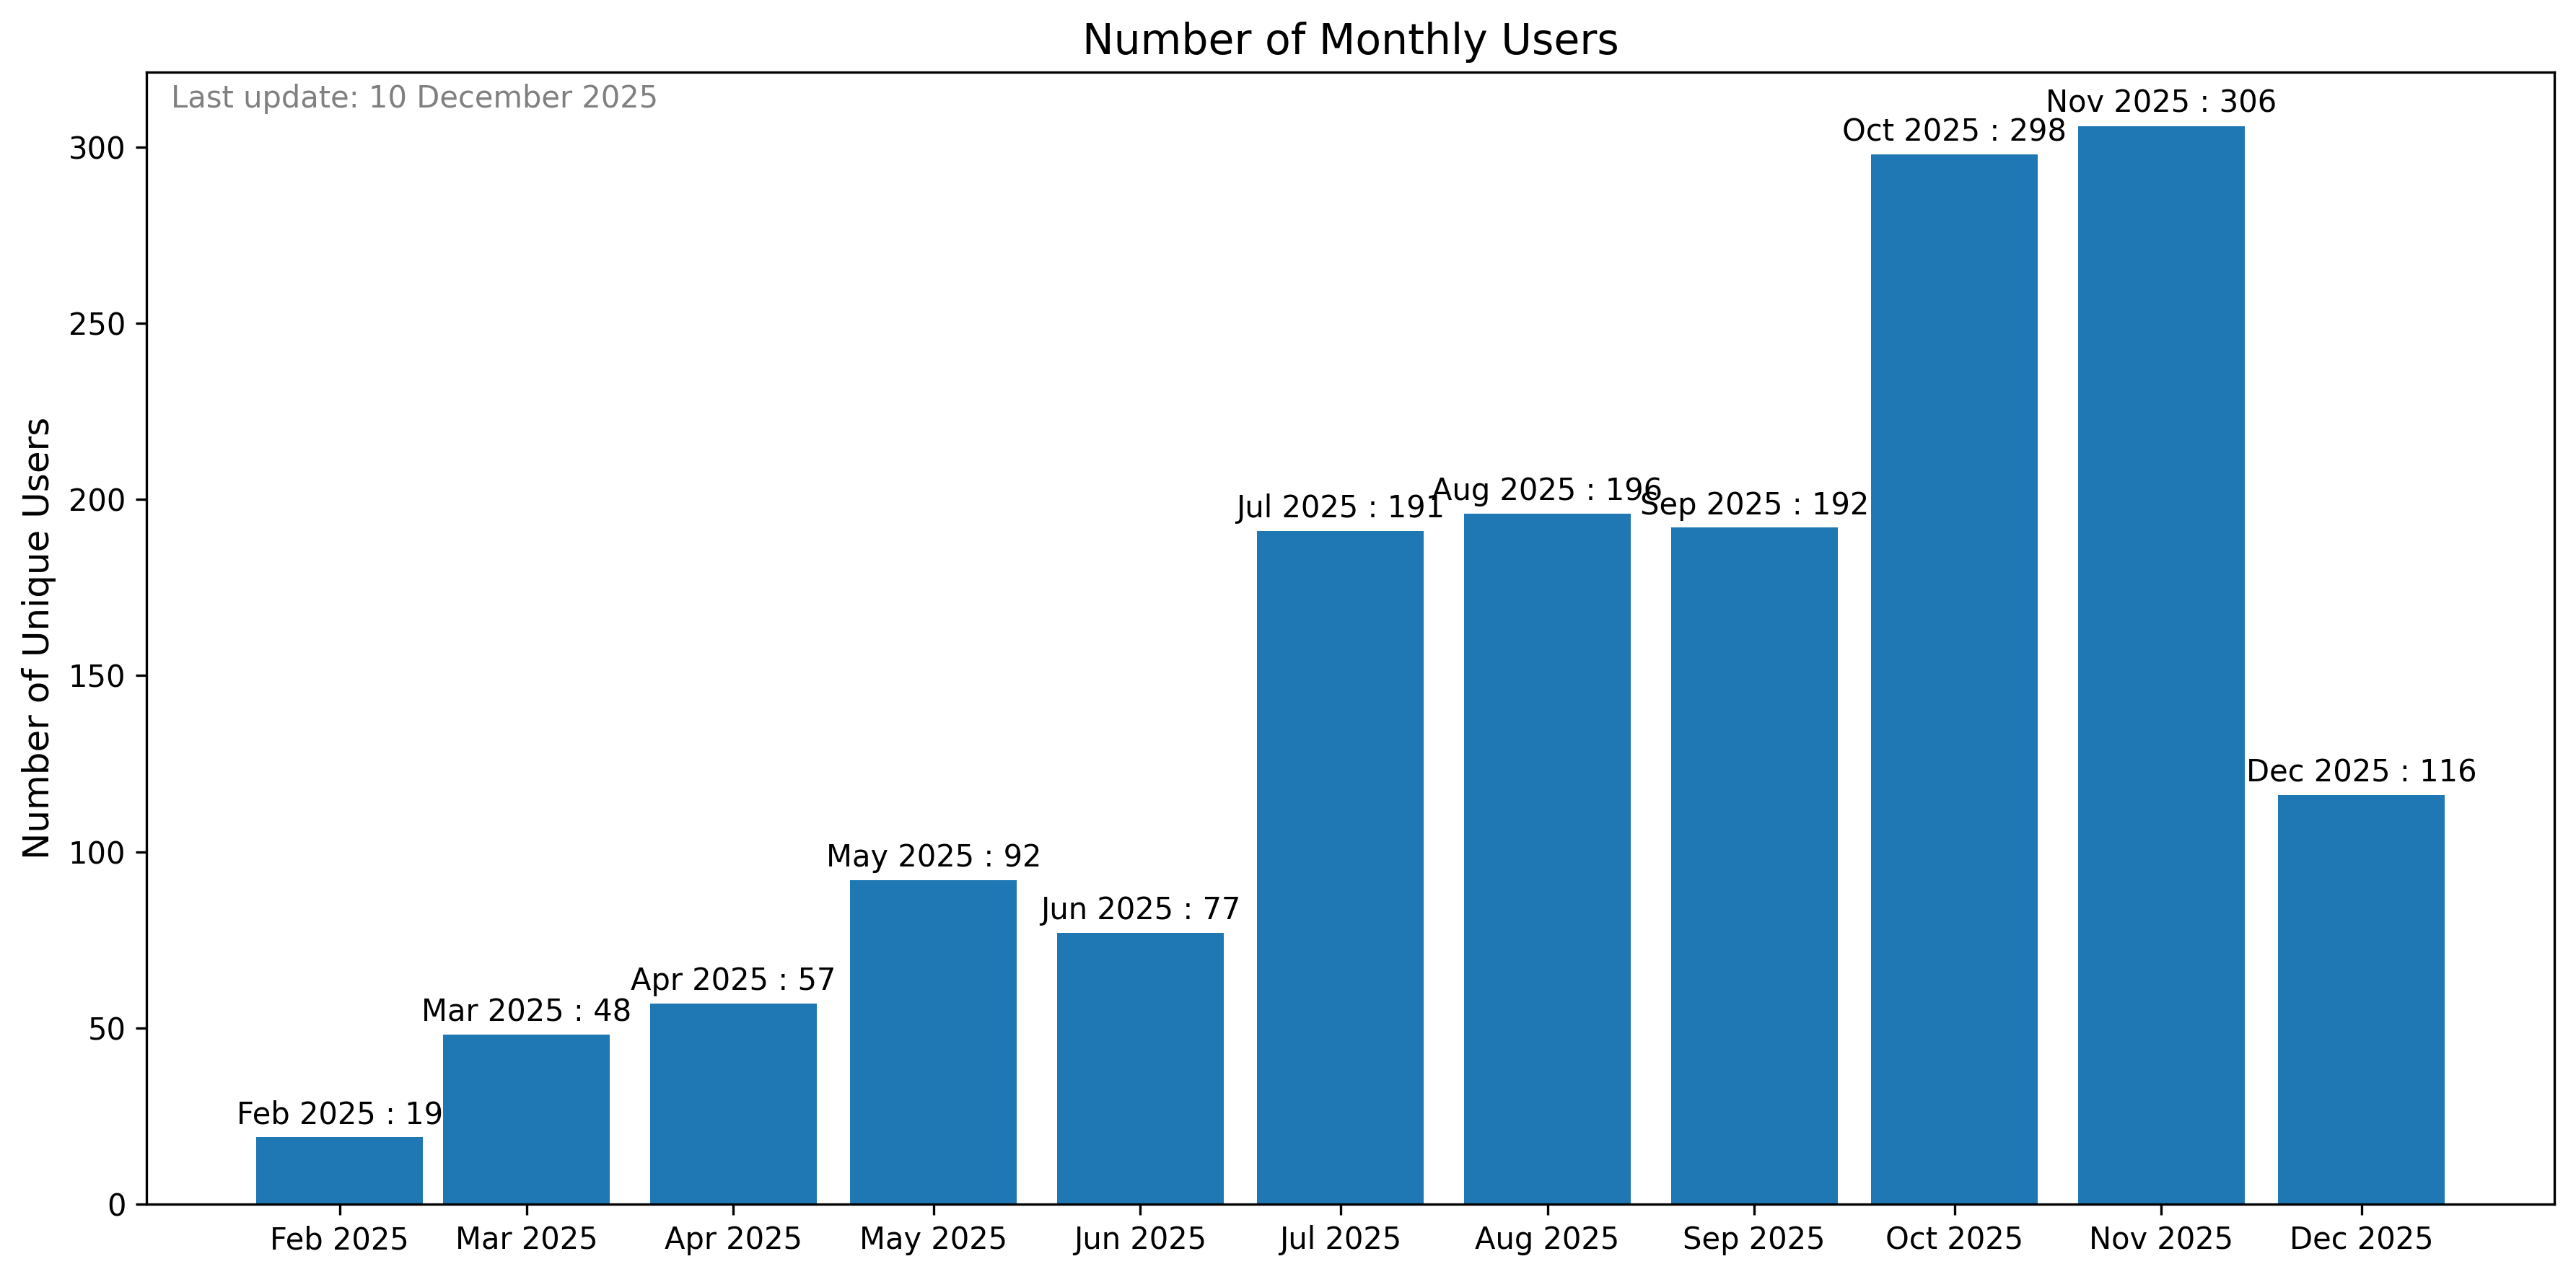

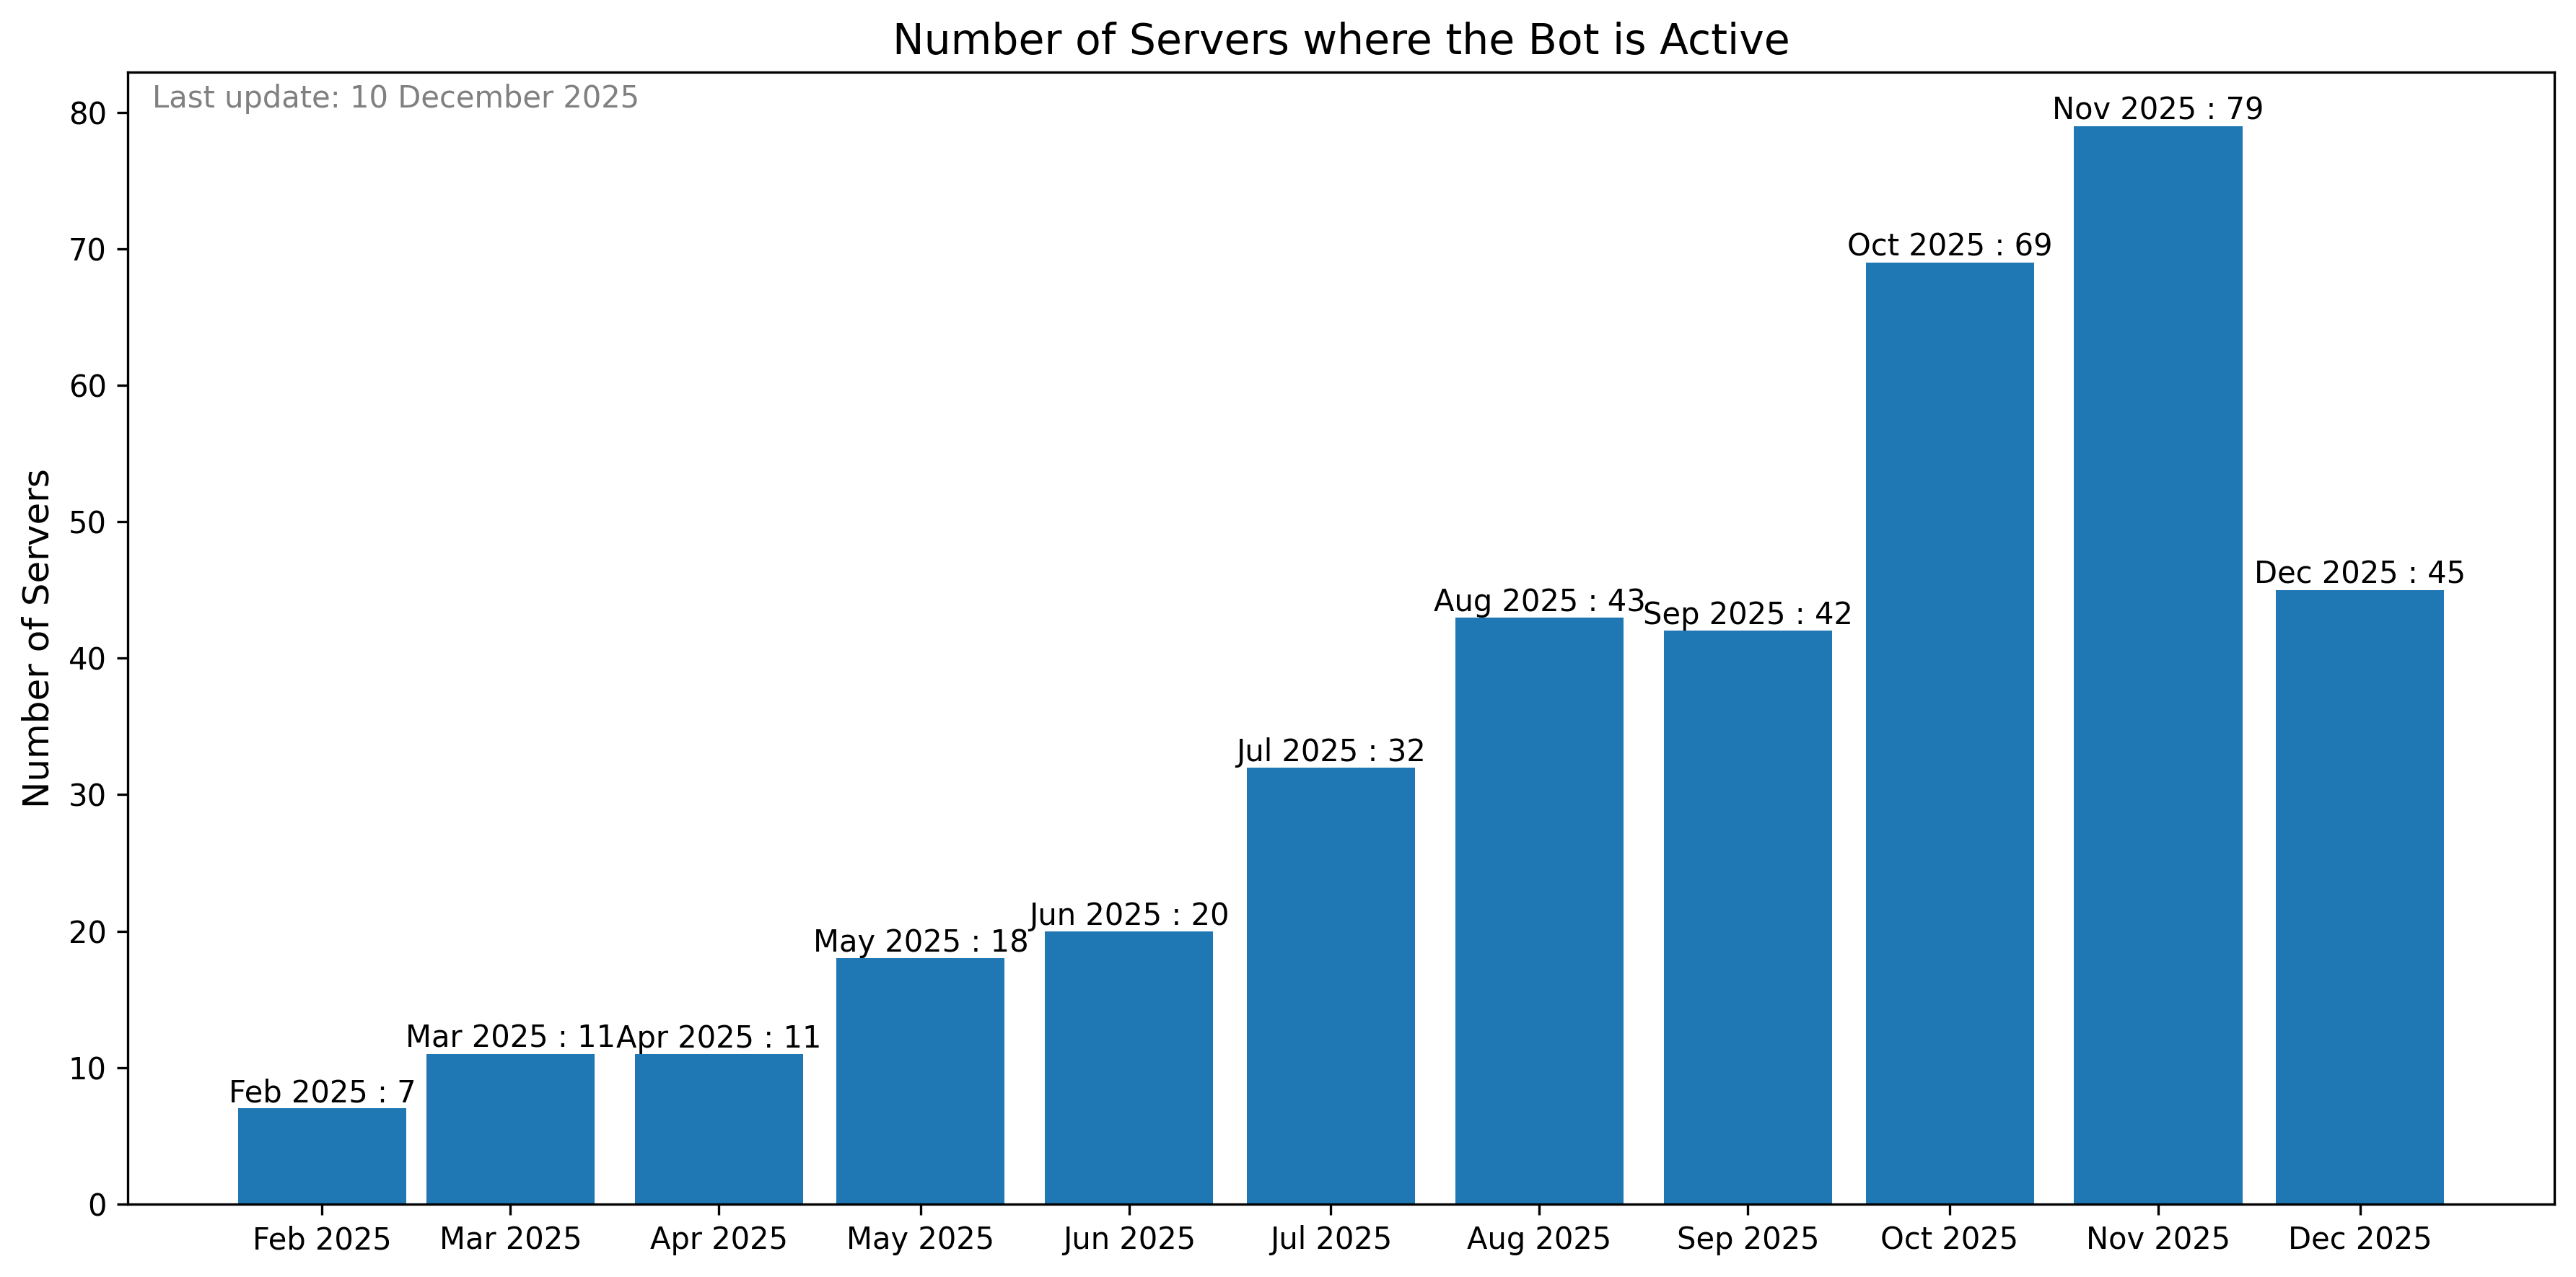

In [17]:
# S'assurer que executed_at est bien en datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# Grouper par mois et compter les utilisateurs uniques
unique_users_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

# Grouper par mois et compter les serveurs uniques
unique_guilds_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()
# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(unique_users_per_month.index, pd.DatetimeIndex):
    unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_users_per_month.index, unique_users_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title("Number of Monthly Users", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Unique Users", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_users_per_month)):
    ax.text(
        unique_users_per_month.index[i],               # X = la vraie date
        unique_users_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{unique_users_per_month.index[i].strftime('%b %Y')} : {unique_users_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()
fig.savefig(img_path+"monthly_users")

# --- Par mois ---
if not isinstance(unique_guilds_per_month.index, pd.DatetimeIndex):
    unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_guilds_per_month.index, unique_guilds_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title("Number of Servers where the Bot is Active", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Servers", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_guilds_per_month)):
    ax.text(
        unique_guilds_per_month.index[i],               # X = la vraie date
        unique_guilds_per_month.iloc[i],                # Y = hauteur de la barre
        f"{unique_guilds_per_month.index[i].strftime('%b %Y')} : {unique_guilds_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )
update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()
fig.savefig(img_path+"monthly_servers")


# arguments les plus utilisés

In [18]:
# top 10 des éléments, classement des classes

logs["arguments_dict"] = logs["arguments"].apply(
    lambda x: json.loads(x) if pd.notnull(x) else {}
)
logs["classe"] = logs["arguments_dict"].apply(lambda d: d.get("classe")).str.lower()
logs["element"] = logs["arguments_dict"].apply(lambda d: d.get("element")).str.lower()

classe_counts = logs["classe"].value_counts(dropna=True)
classe_counts_filtered = classe_counts[classe_counts > 10]
print(classe_counts_filtered)
element_counts = logs["element"].value_counts(dropna=True)
element_counts_filtered = element_counts[element_counts > 10]
print(element_counts_filtered)


classe
ecaflip      376
eniripsa     250
iop          244
cra          239
zobal        237
pandawa      222
sacrieur     221
sadida       211
feca         209
steamer      209
enutrof      181
osamodas     163
sram         159
xelor        145
roublard     126
eliotrope     19
vide          16
Name: count, dtype: int64
element
terre                              743
eau                                440
feu                                405
air                                372
dopou                              221
terre eau                           86
do pou                              79
terre feu                           69
feu eau                             69
cc                                  68
terre cc                            62
eau air                             62
eau feu                             54
feu air                             51
terre air                           46
multi                               41
pp                                  40
soin   

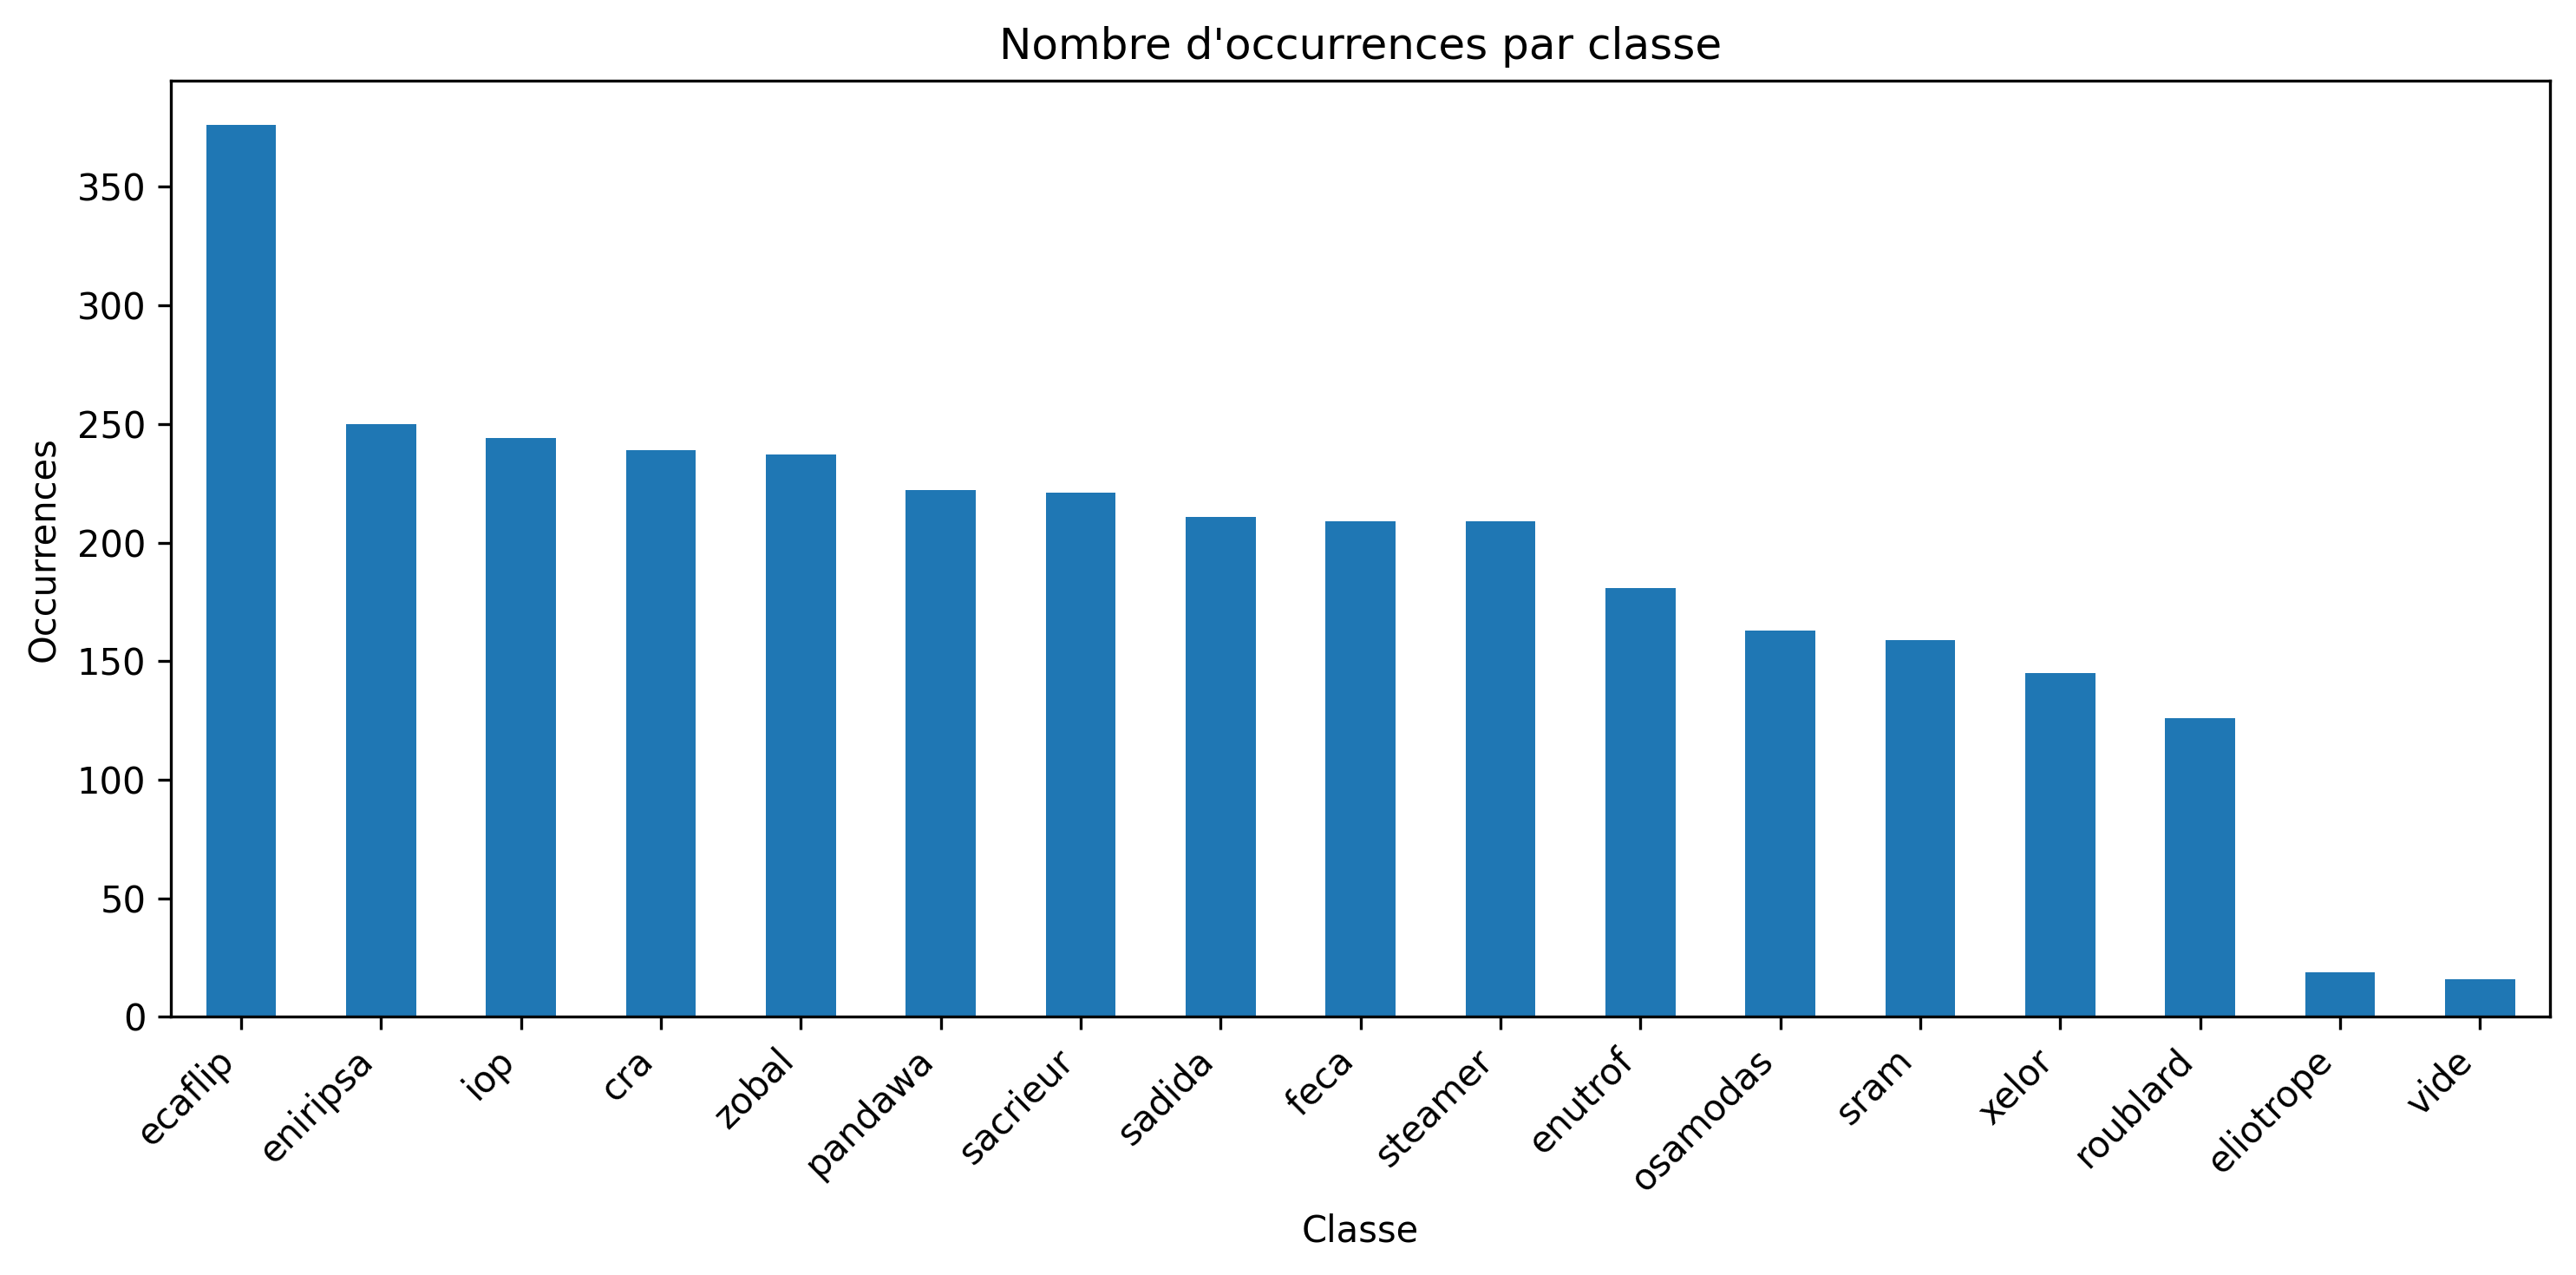

In [19]:
plt.figure(figsize=(10,5), dpi=300)
classe_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par classe")
plt.xlabel("Classe")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


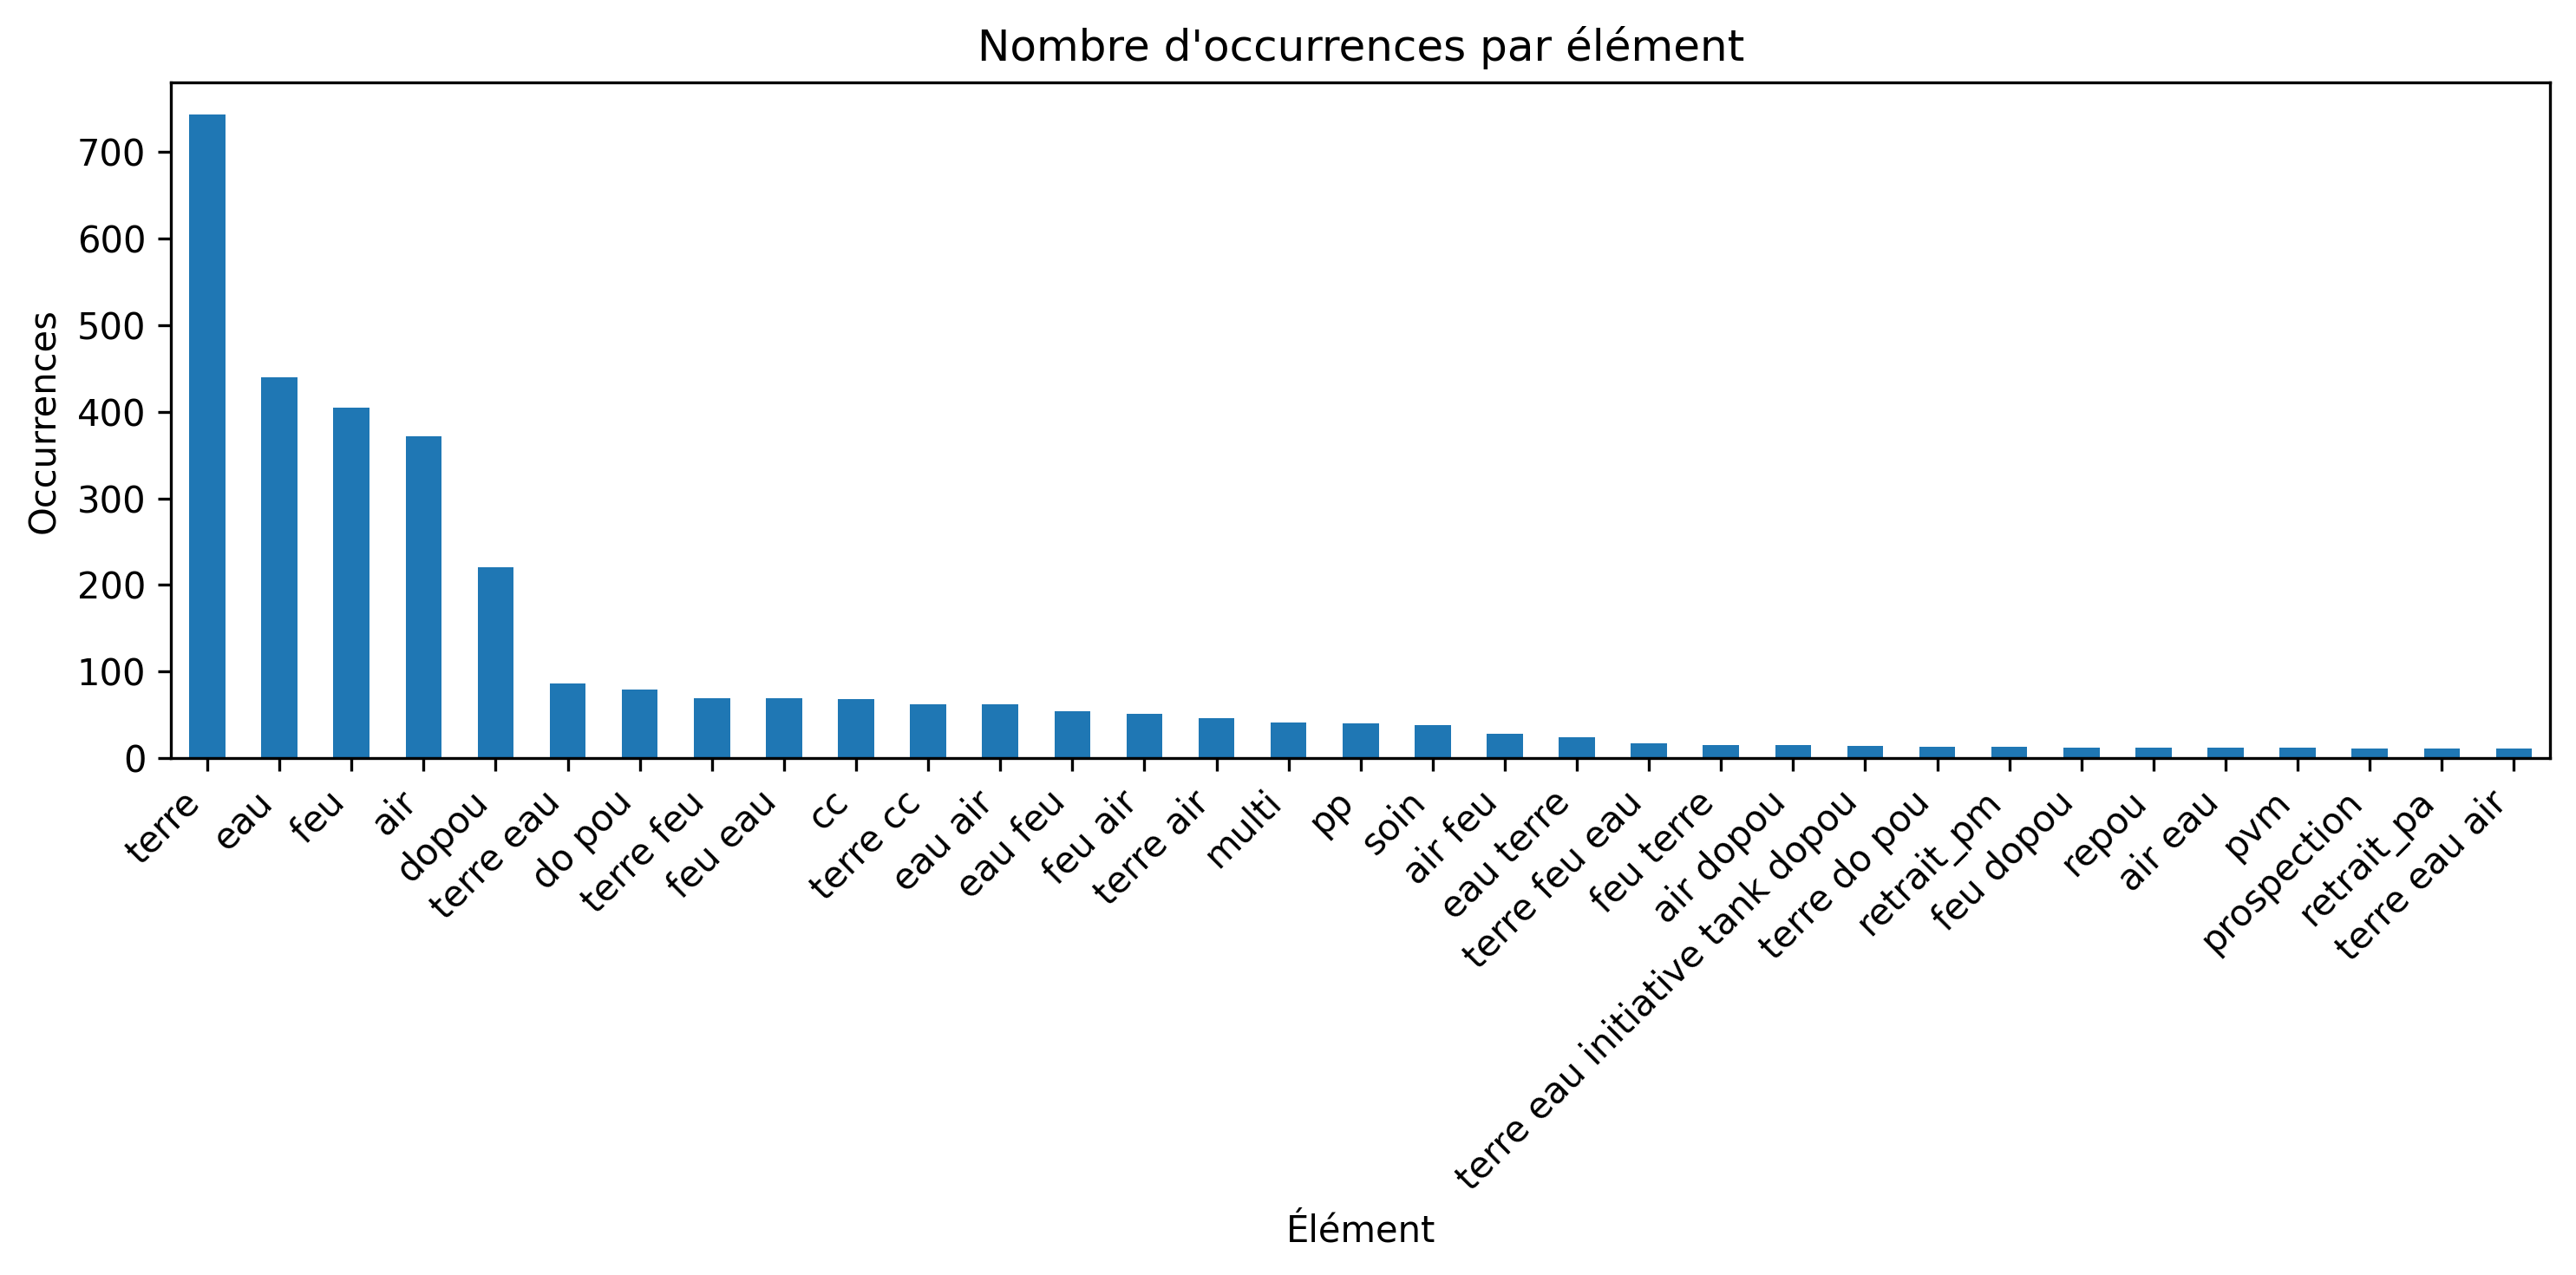

In [20]:
plt.figure(figsize=(10,5), dpi=300)
element_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par élément")
plt.xlabel("Élément")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#fun car do pou ne marche pas mais y'a énormément de gens qui font l'erreur


# MAJ DATE README

In [21]:
# Date de mise à jour
update_date = datetime.now().strftime("%d %B %Y")

# Chemin vers le README
readme_path = "README.md"

# Texte à insérer (Markdown)
update_text = f"""> **Last update : {update_date}**"""

# Lire le README existant
with open(readme_path, "r", encoding="utf-8") as f:
    content = f.read()

conten_split=content.split("<!-- UPDATE_DATE -->")
content_before_date=content.split("<!-- UPDATE_DATE -->")[0]
content_after_date=content.split("<!-- UPDATE_DATE -->")[2:]
new_content = content_before_date+"<!-- UPDATE_DATE -->\n"+ update_text+"\n<!-- UPDATE_DATE -->"+ "/n".join(content_after_date)
print(new_content)
# Écrire le README mis à jour
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(new_content)



# MetaPano
A Discord bot created to offer build recommendations for the game Dofus Touch.

The recommandations are stored in a simple database :   
[DB diagram](https://dbdiagram.io/d/PanoDB-67c5d9b5263d6cf9a010af9b)

If you want to talk about this bot, test it, or follow its news you can join my discord server : 
[Dofus Touls]( https://discord.gg/TcrNrRE5QV)

You can also invite the bot on your server to test it :
[Metapano Invite Link](https://discord.com/oauth2/authorize?client_id=1288167324586872842)


## Usage Analytics
<!-- UPDATE_DATE -->
> **Last update : 10 December 2025**
<!-- UPDATE_DATE -->

### Number of Commands per Month
![Number of Commands per Month](images/dashboard/monthly_commands.png)

### Number of Monthly Users
![Number of Monthly Users](images/dashboard/monthly_users.png)

### Number of Servers where the Bot is Active
![Number of Servers](images/dashboard/monthly_servers.png)


<!-- 
```mermaid
erDiagram
    STUFF {
        DB_id INT PK
        DB_surl CHAR
    